# Análisis de la Base de Datos RETC/SINADER 2024 — Residuos de Construcción y Demolición (RCD)
### Proyecto de Título — Regemac S.A. | Evaluación de Proyectos UC (2026-II)

Este cuaderno explora la base de declaraciones del **RETC (Registro de Emisiones y Transferencias de Contaminantes) / SINADER** para el año 2024, con foco en los residuos de construcción y demolición (capítulo LER 17) a nivel nacional y, en particular, en la Región Metropolitana.

El objetivo es levantar evidencia cuantitativa que informe las decisiones estratégicas descritas en la guía de alineación del proyecto: tamaño de mercado, composición de los residuos, estructura competitiva de los destinatarios finales, tratamiento actual (valorización vs. eliminación) y ubicación geográfica de los actores relevantes — incluyendo a Regemac.

**Fuente:** Datos abiertos RETC, declaraciones de movimiento de residuos 2024 (`df-sinader-2024-ckan`).


---
## 1. Carga de datos

Actualmente los datos maestros se administran en **Google Drive** (planilla original descargada del portal RETC). En paralelo, se mantiene una copia sincronizada en **GitHub** —partida en dos archivos por límite de tamaño— que es la que efectivamente alimenta el resto de este análisis, de modo que el cuaderno pueda ejecutarse sin depender de acceso al Drive personal.

La idea a futuro es migrar por completo a GitHub (o a una base de datos) como fuente única, eliminando la sección de Drive. Por ahora se mantienen ambas secciones visibles para no perder la trazabilidad del origen del dato mientras se completa esa migración.


### 1.1 Fuente maestra: Google Drive (uso actual, exploratorio)

In [ ]:
from google.colab import drive
import pandas as pd

# Esto montará tu Google Drive en el entorno de Colab
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta_excel = '/content/drive/MyDrive/Evalpro/df-sinader-2024-ckan.xlsx'
df_datos_drive = pd.read_excel(ruta_excel, sheet_name='Datos')

razones_df = df_datos_drive['trazabilidad__razon_social'].value_counts()
for categoria, frecuencia in razones_df.items():
    print(f"{categoria} recibe {frecuencia} entregas")

RECUPAC S.A. recibe 2269 entregas
CONSORCIO SANTA MARTA S A recibe 1914 entregas
K D M  S.A. recibe 1458 entregas
RECICLADOS INDUSTRIALES S.A recibe 1086 entregas
RECICLAJES INDUSTRIALES S A recibe 897 entregas
ECOBIO SPA recibe 779 entregas
HIDRONOR CHILE S.A recibe 736 entregas
ECOFIBRAS S A recibe 653 entregas
ECOMAULE SPA recibe 592 entregas
VEOLIA SU CHILE S.A. recibe 583 entregas
ACEROS AZA S.A. recibe 555 entregas
RELLENOS SANITARIOS DEL MAULE S A recibe 539 entregas
BRAVO ENERGY SPA recibe 528 entregas
ASESORIAS LOS OLIVOS S.A. recibe 456 entregas
RECYCLING S.A. recibe 418 entregas
CEMENTO POLPAICO S A recibe 398 entregas
RESIDUOS INDUSTRIALES DEL SUR LTDA recibe 396 entregas
CRISTALERIAS TORO SPA recibe 354 entregas
GESTION INTEGRAL DE RESIDUOS SPA recibe 351 entregas
INDUSTRIAL Y MINERA LOS ESTEROS LIMITADA recibe 309 entregas
SOC COMERCIAL DEGRAF SPA recibe 302 entregas
PAUQUE RECICLAR LIMITADA recibe 292 entregas
INVERSIONES PANUL LIMITADA recibe 291 entregas
MANEJO INTEGRA

In [ ]:
ruta_excel2 = '/content/drive/MyDrive/Evalpro/irar-sinader-2024-ckan.xlsx'
irar_datos_drive = pd.read_excel(ruta_excel2, sheet_name='Datos')

razones_irar = irar_datos_drive['trazabilidad__razon_social'].value_counts()
for categoria, frecuencia in razones_irar.items():
    print(f"{categoria} recibe {frecuencia} entregas")

ECO LOGICA S A recibe 757 entregas
ENFAENA S.A. recibe 404 entregas
REXIN SPA recibe 365 entregas
RECUPERADORA DE EXCEDENTES INDUSTRIALES RODOLFO RUBEN ORTIZ FUENZALIDA recibe 364 entregas
RST RESIDUOS SPA recibe 335 entregas
SOC RECUPERADORA DE PAPEL SPA recibe 331 entregas
REMAP SPA recibe 319 entregas
ECOBIO SPA recibe 312 entregas
GESTION ECOLOGICA DE RESIDUOS S A recibe 302 entregas
RECYCLA CHILE S A recibe 279 entregas
RECICLADOS INDUSTRIALES S.A recibe 268 entregas
COMERCIAL RIO ACONCAGUA SPA recibe 267 entregas
RECICLAJE RECREA PATAGONIA LIMITADA recibe 249 entregas
RESITER INDUSTRIAL S.A. recibe 248 entregas
ACEROS AZA S.A. recibe 211 entregas
AMBIPAR RECYNOR SPA recibe 211 entregas
COMERCIAL PRAXEDES DEL ROSARIO PIZARRO LANDERO SPA recibe 196 entregas
RECUPAC S.A. recibe 196 entregas
COMERCIAL BENDITO RESIDUO SPA recibe 186 entregas
HOPE SPA recibe 185 entregas
REMBRE SPA. recibe 175 entregas
MARIO ENRIQUE ESPEJO PAREDES recibe 166 entregas
SOC RECUPERADORA DE PAPELES Y CARTO

### 1.2 Fuente de trabajo: GitHub (versión pública, la que usa el resto del cuaderno)

> **Nota de migración:** este es el bloque que en definitiva se ejecuta para todo el análisis que sigue. Cuando la migración esté completa, la sección 1.1 podrá eliminarse sin afectar nada de lo de abajo.

In [ ]:
import pandas as pd

link1 = "https://raw.githubusercontent.com/fernando25132/Evalpro/refs/heads/main/df-sinader-2024-ckan_Datos_Parte1.csv"
link2 = "https://raw.githubusercontent.com/fernando25132/Evalpro/refs/heads/main/df-sinader-2024-ckan_Datos_Parte2.csv"
df_datos_parte1 = pd.read_csv(link1)
df_datos_parte2 = pd.read_csv(link2)
df_datos = pd.concat([df_datos_parte1, df_datos_parte2], ignore_index=True)

link3 = "https://raw.githubusercontent.com/fernando25132/Evalpro/refs/heads/main/df-sinader-2024-ckan_Resumen.csv"
df_resumen = pd.read_csv(link3)

print(f"Filas cargadas: {len(df_datos):,}")
df_datos.head()

Filas cargadas: 39,395


,año,mes,id_vu,razon_social,rut_razon_social,nombre_establecimiento,rubro,rubro_id,ciiu4,ciiu4_id,...,LER_capitulo,LER_numero_capitulo,LER_subcapitulo,LER_numero_subcapitulo,trazabilidad__id_vu,trazabilidad__nombre_establecimiento,trazabilidad__razon_social,trazabilidad__comuna,trazabilidad__region,trazabilidad__pais
0,2024,8,45,CIA MINERA CERRO COLORADO LTDA,94621000-5,CIA. MINERA CERRO COLORADO LTDA.,Minería,4,Extracción y procesamiento de cobre,B0400,...,"15 | Residuos de envases; absorbentes, trapos ...",15,01 | Envases (incluidos los residuos de envase...,1,45.0,CIA. MINERA CERRO COLORADO LTDA.,CIA MINERA CERRO COLORADO LTDA,Pozo Almonte,Tarapacá,Chile
1,2024,7,45,CIA MINERA CERRO COLORADO LTDA,94621000-5,CIA. MINERA CERRO COLORADO LTDA.,Minería,4,Extracción y procesamiento de cobre,B0400,...,"15 | Residuos de envases; absorbentes, trapos ...",15,01 | Envases (incluidos los residuos de envase...,1,45.0,CIA. MINERA CERRO COLORADO LTDA.,CIA MINERA CERRO COLORADO LTDA,Pozo Almonte,Tarapacá,Chile
2,2024,6,45,CIA MINERA CERRO COLORADO LTDA,94621000-5,CIA. MINERA CERRO COLORADO LTDA.,Minería,4,Extracción y procesamiento de cobre,B0400,...,"15 | Residuos de envases; absorbentes, trapos ...",15,01 | Envases (incluidos los residuos de envase...,1,45.0,CIA. MINERA CERRO COLORADO LTDA.,CIA MINERA CERRO COLORADO LTDA,Pozo Almonte,Tarapacá,Chile
3,2024,4,45,CIA MINERA CERRO COLORADO LTDA,94621000-5,CIA. MINERA CERRO COLORADO LTDA.,Minería,4,Extracción y procesamiento de cobre,B0400,...,"15 | Residuos de envases; absorbentes, trapos ...",15,01 | Envases (incluidos los residuos de envase...,1,45.0,CIA. MINERA CERRO COLORADO LTDA.,CIA MINERA CERRO COLORADO LTDA,Pozo Almonte,Tarapacá,Chile
4,2024,3,45,CIA MINERA CERRO COLORADO LTDA,94621000-5,CIA. MINERA CERRO COLORADO LTDA.,Minería,4,Extracción y procesamiento de cobre,B0400,...,"15 | Residuos de envases; absorbentes, trapos ...",15,01 | Envases (incluidos los residuos de envase...,1,45.0,CIA. MINERA CERRO COLORADO LTDA.,CIA MINERA CERRO COLORADO LTDA,Pozo Almonte,Tarapacá,Chile


In [ ]:
razon_social_establecimientos = df_datos['trazabilidad__razon_social'].value_counts()
for categoria, frecuencia in razon_social_establecimientos.items():
    print(f"{categoria} recibe {frecuencia} entregas")

RECUPAC S.A. recibe 2269 entregas
CONSORCIO SANTA MARTA S A recibe 1914 entregas
K D M  S.A. recibe 1458 entregas
RECICLADOS INDUSTRIALES S.A recibe 1086 entregas
RECICLAJES INDUSTRIALES S A recibe 897 entregas
ECOBIO SPA recibe 779 entregas
HIDRONOR CHILE S.A recibe 736 entregas
ECOFIBRAS S A recibe 653 entregas
ECOMAULE SPA recibe 592 entregas
VEOLIA SU CHILE S.A. recibe 583 entregas
ACEROS AZA S.A. recibe 555 entregas
RELLENOS SANITARIOS DEL MAULE S A recibe 539 entregas
BRAVO ENERGY SPA recibe 528 entregas
ASESORIAS LOS OLIVOS S.A. recibe 456 entregas
RECYCLING S.A. recibe 418 entregas
CEMENTO POLPAICO S A recibe 398 entregas
RESIDUOS INDUSTRIALES DEL SUR LTDA recibe 396 entregas
CRISTALERIAS TORO SPA recibe 354 entregas
GESTION INTEGRAL DE RESIDUOS SPA recibe 351 entregas
INDUSTRIAL Y MINERA LOS ESTEROS LIMITADA recibe 309 entregas
SOC COMERCIAL DEGRAF SPA recibe 302 entregas
PAUQUE RECICLAR LIMITADA recibe 292 entregas
INVERSIONES PANUL LIMITADA recibe 291 entregas
MANEJO INTEGRA

---
## 2. Preparación de los datos

Antes de graficar, dejamos listas tres cosas que se usan de forma transversal en todo el cuaderno:

1. **Filtro a RCD** (capítulo LER 17) y recorte a la Región Metropolitana.
2. **Etiquetas cortas para los códigos LER**, porque los nombres oficiales son extensos (p. ej. *"Mezclas de hormigón, ladrillos, tejas y materiales cerámicos, distintas de las especificadas en el código 17 01 06"*) y saturan cualquier gráfico de barras. Se define un diccionario de traducción a nombres breves, con un *fallback* automático para códigos no mapeados explícitamente.
3. **Utilidades de estilo** (ajuste de títulos largos con salto de línea, tema visual consistente) para que ningún gráfico quede con texto cortado o superpuesto.


In [ ]:
# Filtrar el DataFrame para quedarte solo con RCD (capítulo LER 17)
df_rcd = df_datos[df_datos['LER_numero_capitulo'] == 17].copy()
print(f"Total de declaraciones de RCD en Chile (2024): {len(df_rcd)} de {len(df_datos)}")

df_rcd_rm = df_rcd[df_rcd['region'] == 'Metropolitana de Santiago'].copy()
print(f"De ellas, en la Región Metropolitana: {len(df_rcd_rm)}")

df_rcd.head()

Total de declaraciones de RCD en Chile (2024): 4463 de 39395
De ellas, en la Región Metropolitana: 2345


,año,mes,id_vu,razon_social,rut_razon_social,nombre_establecimiento,rubro,rubro_id,ciiu4,ciiu4_id,...,LER_capitulo,LER_numero_capitulo,LER_subcapitulo,LER_numero_subcapitulo,trazabilidad__id_vu,trazabilidad__nombre_establecimiento,trazabilidad__razon_social,trazabilidad__comuna,trazabilidad__region,trazabilidad__pais
28,2024,1,633,CIA SIDERURGICA HUACHIPATO S.A.,94637000-2,COMPAÑÍA SIDERÚRGICA HUACHIPATO,Otras industrias manufactureras,10,Industrias básicas de hierro y acero,C2410,...,17 | Residuos de la construcción y demolición,17,04 | Metales (incluidas sus aleaciones),4,633.0,COMPAÑÍA SIDERÚRGICA HUACHIPATO,CIA SIDERURGICA HUACHIPATO S.A.,Talcahuano,Biobío,Chile
29,2024,1,633,CIA SIDERURGICA HUACHIPATO S.A.,94637000-2,COMPAÑÍA SIDERÚRGICA HUACHIPATO,Otras industrias manufactureras,10,Industrias básicas de hierro y acero,C2410,...,17 | Residuos de la construcción y demolición,17,04 | Metales (incluidas sus aleaciones),4,633.0,COMPAÑÍA SIDERÚRGICA HUACHIPATO,CIA SIDERURGICA HUACHIPATO S.A.,Talcahuano,Biobío,Chile
43,2024,2,633,CIA SIDERURGICA HUACHIPATO S.A.,94637000-2,COMPAÑÍA SIDERÚRGICA HUACHIPATO,Otras industrias manufactureras,10,Industrias básicas de hierro y acero,C2410,...,17 | Residuos de la construcción y demolición,17,04 | Metales (incluidas sus aleaciones),4,633.0,COMPAÑÍA SIDERÚRGICA HUACHIPATO,CIA SIDERURGICA HUACHIPATO S.A.,Talcahuano,Biobío,Chile
46,2024,2,633,CIA SIDERURGICA HUACHIPATO S.A.,94637000-2,COMPAÑÍA SIDERÚRGICA HUACHIPATO,Otras industrias manufactureras,10,Industrias básicas de hierro y acero,C2410,...,17 | Residuos de la construcción y demolición,17,04 | Metales (incluidas sus aleaciones),4,633.0,COMPAÑÍA SIDERÚRGICA HUACHIPATO,CIA SIDERURGICA HUACHIPATO S.A.,Talcahuano,Biobío,Chile
236,2024,1,1967,CRISTALERIAS TORO SPA,93372000-4,CRISTALERIAS TORO SPA,Otras industrias manufactureras,10,Fabricación de vidrio y productos de vidrio,C2310,...,17 | Residuos de la construcción y demolición,17,"02 | Madera, vidrio y plástico",2,1967.0,CRISTALERIAS TORO SPA,CRISTALERIAS TORO SPA,Cerrillos,Metropolitana de Santiago,Chile


In [ ]:
# Ver de qué comunas proviene el residuo que termina en los establecimientos de Puente Alto
rcd_puente_alto = df_rcd[df_rcd['trazabilidad__comuna'] == 'Puente Alto']
rutas_origen = rcd_puente_alto['comuna'].value_counts()
print("Comunas de origen de los RCD que viajan a Puente Alto:")
print(rutas_origen.head(10))

Comunas de origen de los RCD que viajan a Puente Alto:
comuna
Puente Alto    337
Cerrillos       12
La Pintana      12
Huechuraba       6
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

sns.set_theme(style="whitegrid")
PALETA = "colorblind"

def wrap_title(texto, width=58):
    """Corta títulos largos en varias líneas para que nunca se salgan del gráfico."""
    return "\n".join(textwrap.wrap(texto, width=width))

# Diccionario de nombres cortos para los códigos LER que más se repiten en los gráficos.
# Cualquier código no listado aquí usa un acortamiento automático (ver `etiqueta_corta`).
LER_NOMBRES_CORTOS = {
    "17 09 04": "Mezcla no clasificada de RCD",
    "17 02 01": "Madera limpia",
    "17 01 01": "Hormigón",
    "17 04 07": "Metales mezclados",
    "17 04 05": "Hierro y acero (no galv.)",
    "17 01 07": "Escombros mixtos (hormigón/ladrillo)",
    "17 02 03": "Plástico (otros)",
    "17 04 02": "Aluminio",
    "17 05 04": "Tierra y piedras",
    "17 04 12": "Hierro y acero (galvanizado)",
    "17 08 02": "Placas de yeso-cartón",
    "17 02 07": "Plástico PVC",
    "17 02 02": "Vidrio",
    "17 03 02": "Mezclas bituminosas (asfalto)",
    "17 06 04": "Aislamiento (sin amianto)",
    "17 04 11": "Cables",
    "17 04 04": "Zinc",
    "17 04 03": "Plomo",
    "17 04 01": "Cobre, bronce, latón",
    "17 01 03": "Tejas y cerámicos",
}

def etiqueta_corta(ler_code_full, max_len=35):
    """Convierte 'CODIGO | Nombre larguísimo, con detalle...' en 'CODIGO · Nombre breve'."""
    codigo = ler_code_full[:8]
    if codigo in LER_NOMBRES_CORTOS:
        return f"{codigo} · {LER_NOMBRES_CORTOS[codigo]}"
    nombre = ler_code_full.split("|", 1)[-1].strip().split(",")[0]
    if len(nombre) > max_len:
        nombre = nombre[: max_len - 3] + "..."
    return f"{codigo} · {nombre}"

> **Nota metodológica (dato de calidad de datos, útil para el Anexo 2 de limitaciones):** al explorar las coordenadas de los destinatarios declarados como región `Metropolitana de Santiago`, se detectaron ~164 registros cuya comuna real corresponde a otras regiones (Puerto Montt, Coihaique, Antofagasta, Copiapó, etc.), es decir, errores de estandarización en la base RETC. Esto no afecta los conteos por región (se usa el campo `region` tal como viene declarado), pero **sí** hay que filtrarlos antes de dibujar el mapa geográfico, o el gráfico queda dominado por un par de puntos a cientos de kilómetros de Santiago. Ese filtro se aplica explícitamente en la sección 10.

---
## 3. Composición de los RCD declarados

El gráfico original ordenaba los materiales por **número de declaraciones**. Eso es útil para saber qué tan seguido se declara cada tipo de residuo, pero no dice nada sobre el volumen físico que efectivamente hay que procesar. Por eso se agrega una segunda vista por **tonelaje**, que es la que más le importa a una planta de segregación (dimensionamiento de líneas, logística, capacidad de acopio).

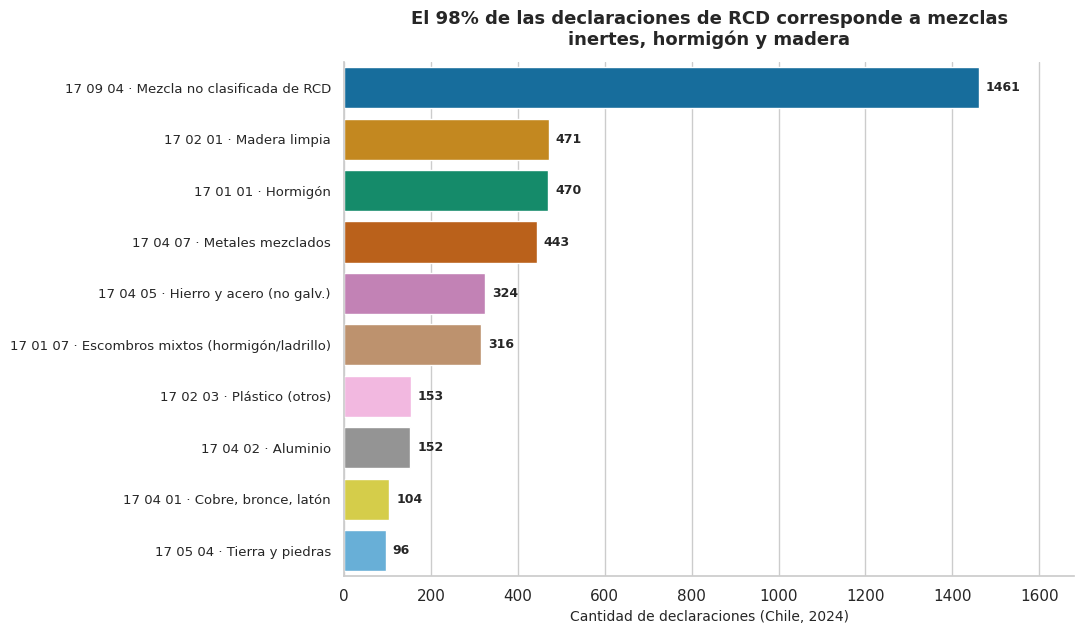

In [ ]:
materiales_counts = df_rcd['LER'].value_counts().head(10)
labels_cortas = [etiqueta_corta(x) for x in materiales_counts.index]

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(x=materiales_counts.values, y=labels_cortas, hue=labels_cortas, legend=False, palette=PALETA, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontweight='bold', padding=5, fontsize=9)
ax.set_xlim(0, materiales_counts.values.max() * 1.15)
ax.set_title(wrap_title("El 98% de las declaraciones de RCD corresponde a mezclas inertes, hormigón y madera", 58),
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Cantidad de declaraciones (Chile, 2024)", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis='y', labelsize=9.5)
sns.despine()
plt.tight_layout()
plt.show()

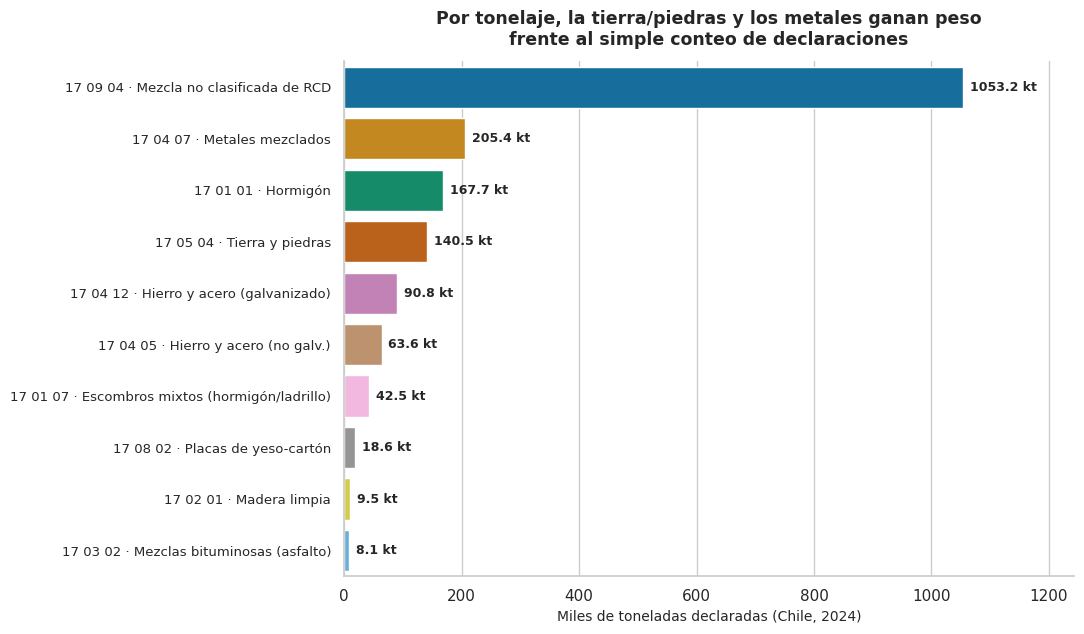

In [ ]:
tonelaje_material = df_rcd.groupby('LER')['cantidad_toneladas'].sum().sort_values(ascending=False).head(10)
labels_ton = [etiqueta_corta(x) for x in tonelaje_material.index]

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(x=tonelaje_material.values / 1000, y=labels_ton, hue=labels_ton, legend=False, palette=PALETA, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f kt', fontweight='bold', padding=5, fontsize=9)
ax.set_xlim(0, tonelaje_material.values.max() / 1000 * 1.18)
ax.set_title(wrap_title("Por tonelaje, la tierra/piedras y los metales ganan peso frente al simple conteo de declaraciones", 58),
             fontsize=12.5, fontweight='bold', pad=12)
ax.set_xlabel("Miles de toneladas declaradas (Chile, 2024)", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis='y', labelsize=9.5)
sns.despine()
plt.tight_layout()
plt.show()

**Lectura conjunta de ambos gráficos:** materiales como el aluminio o el cobre aparecen entre los más *frecuentes* en declaraciones, pero prácticamente desaparecen al mirar el *tonelaje* — son livianos y se declaran seguido en lotes pequeños. Lo inverso pasa con la tierra y piedras: pocas declaraciones, pero de gran volumen. Para dimensionar la planta (capacidad de trommel, cinta, imán overbelt) el criterio relevante es el tonelaje; para estimar la frecuencia de camiones y turnos de triaje, importa también el conteo.

---
## 4. Estacionalidad mensual en la Región Metropolitana

Nuevo respecto del análisis original: la base tiene granularidad mensual para todo 2024, lo que permite revisar si existen meses de mayor/menor generación de RCD — relevante para dimensionar turnos y para el supuesto de estacionalidad en la demanda que pide la pauta académica (Pilar 1).

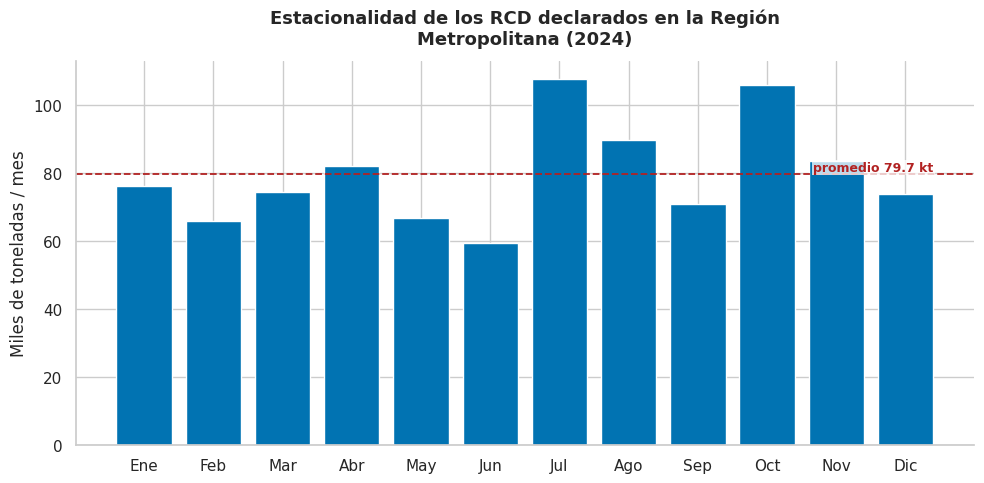

In [ ]:
meses_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
mensual = df_rcd_rm.groupby('mes')['cantidad_toneladas'].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(meses_es, mensual.values / 1000, color=sns.color_palette(PALETA)[0])
prom = mensual.mean() / 1000
ax.axhline(prom, color='firebrick', linestyle='--', linewidth=1.3)
ax.text(11.4, prom, f"promedio {prom:.1f} kt", color='firebrick', fontsize=9, va='bottom', ha='right',
        fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1))
ax.set_title(wrap_title("Estacionalidad de los RCD declarados en la Región Metropolitana (2024)", 58),
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("Miles de toneladas / mes")
sns.despine()
plt.tight_layout()
plt.show()

Julio y octubre destacan por sobre el resto (~30-35% por encima del promedio), mientras junio es el mes más bajo. Con solo un año de datos no se puede separar estacionalidad real de ruido de reporte (declaraciones atrasadas, cierres administrativos), así que esto debe tomarse como una primera señal a contrastar con series de años adicionales del RETC si están disponibles, no como una estacionalidad confirmada.

---
## 5. Comparación multi-año en la Región Metropolitana (2021-2024)

Todo lo visto hasta acá usa solo el año 2024. El portal RETC publica también años anteriores, así que se incorporan **2021, 2022 y 2023** (los últimos disponibles en el repositorio del proyecto antes de 2024) para dar algo de perspectiva histórica al tamaño de mercado.

**Advertencia metodológica importante, antes de mirar cualquier número:** la forma de declarar cambió entre 2023 y 2024. Los años 2021-2023 no tienen fecha de declaración (solo el campo `año`) y el volumen de registros es muchísimo menor — todo indica que son declaraciones **anuales agregadas por establecimiento y tipo de residuo**, mientras que 2024 aporta **~2.345 declaraciones** con detalle mensual, prácticamente una por movimiento. Esto tiene dos consecuencias directas:

1. **La estacionalidad mensual de la sección 4 no se puede validar contra años anteriores** — ninguno de 2021-2023 tiene campo de fecha o mes.
2. **El salto en número de declaraciones entre 2023 y 2024 no debe leerse como crecimiento real del mercado.** Por eso la comparación entre años se hace principalmente por **tonelaje** (más comparable) y no por conteo de declaraciones.

In [ ]:
def cargar_retc_anio(nombre_archivo, encoding):
    """Carga un CSV RETC de años anteriores (2021-2023): separador ';', decimales con coma."""
    url = f"https://raw.githubusercontent.com/fernando25132/Evalpro/refs/heads/main/{nombre_archivo}"
    return pd.read_csv(url, sep=';', encoding=encoding, decimal=',', low_memory=False)

archivos_anteriores = [
    (2021, 'df-sinader-2021-ckan.csv', 'utf-8-sig'),
    (2022, 'df-sinader-2022-ckan.csv', 'utf-8-sig'),
    (2023, 'df-sinader-2023-ckan.csv', 'latin1'),
]

nombre_regemac = 'REGENERADORA DE MATERIALES DE CONSTRUCCION S A'
resumen_anual = []

for anio, archivo, enc in archivos_anteriores:
    d = cargar_retc_anio(archivo, enc)
    rcd_rm_anio = d[(d['capitulo_ler'].astype(str).str.startswith('17')) &
                    (d['region'] == 'Metropolitana de Santiago')]
    ton_por_actor = rcd_rm_anio.groupby('razon_social')['cantidad_toneladas'].sum()
    ton_regemac = ton_por_actor.get(nombre_regemac, 0.0)
    resumen_anual.append({
        'año': anio,
        'declaraciones': len(rcd_rm_anio),
        'toneladas': rcd_rm_anio['cantidad_toneladas'].sum(),
        'establecimientos': rcd_rm_anio['razon_social'].nunique(),
        'ton_regemac': ton_regemac,
        'share_regemac_%': (ton_regemac / ton_por_actor.sum() * 100) if ton_por_actor.sum() > 0 else 0.0,
        'granularidad': 'anual agregada',
    })

# Se agrega 2024 (ya cargado y filtrado en la sección 2) para completar la serie
ton_por_actor_2024 = df_rcd_rm.groupby('trazabilidad__razon_social')['cantidad_toneladas'].sum()
resumen_anual.append({
    'año': 2024,
    'declaraciones': len(df_rcd_rm),
    'toneladas': df_rcd_rm['cantidad_toneladas'].sum(),
    'establecimientos': df_rcd_rm['trazabilidad__razon_social'].nunique(),
    'ton_regemac': ton_por_actor_2024.get(nombre_regemac, 0.0),
    'share_regemac_%': ton_por_actor_2024.get(nombre_regemac, 0.0) / ton_por_actor_2024.sum() * 100,
    'granularidad': 'mensual / por movimiento',
})

df_resumen_anual = pd.DataFrame(resumen_anual)
df_resumen_anual

,año,declaraciones,toneladas,establecimientos,ton_regemac,share_regemac_%,granularidad
0,2021,46,216550.230000,12,0.000,0.000000,anual agregada
1,2022,271,433114.544200,33,117835.321,27.206503,anual agregada
2,2023,211,419214.753030,47,60303.892,14.384964,anual agregada
3,2024,2345,956012.234756,88,118456.781,12.395768,mensual / por movimiento


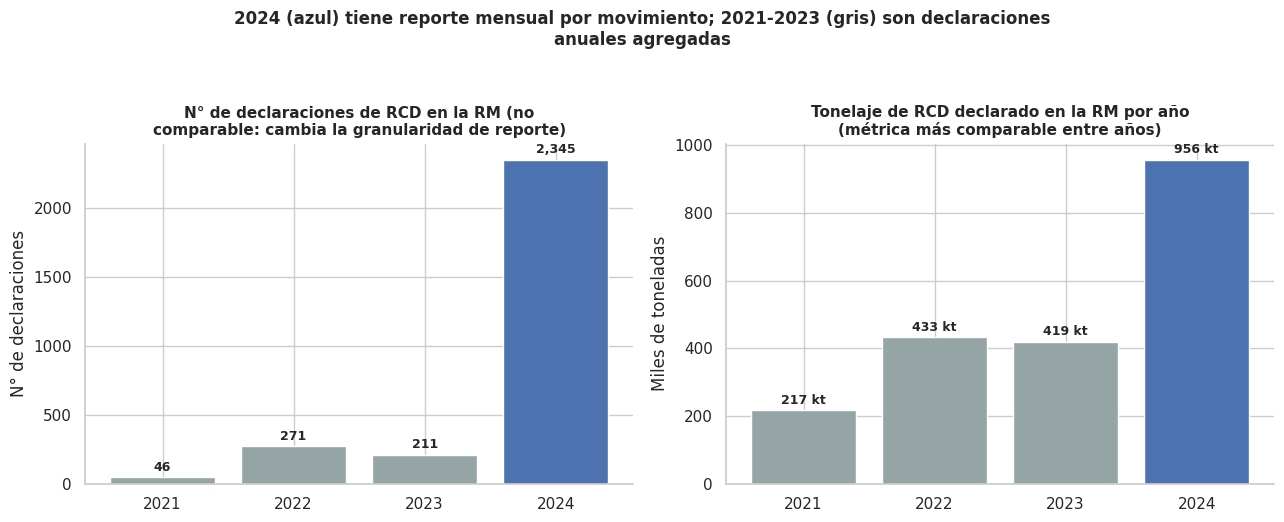

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_barras_anio = ['#95A5A6' if a != 2024 else '#4C72B0' for a in df_resumen_anual['año']]

axes[0].bar(df_resumen_anual['año'].astype(str), df_resumen_anual['declaraciones'], color=colores_barras_anio)
for x, v in enumerate(df_resumen_anual['declaraciones']):
    axes[0].text(x, v + max(df_resumen_anual['declaraciones']) * 0.02, f"{v:,}", ha='center', fontsize=9, fontweight='bold')
axes[0].set_title(wrap_title("N° de declaraciones de RCD en la RM (no comparable: cambia la granularidad de reporte)", 48),
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel("N° de declaraciones")

axes[1].bar(df_resumen_anual['año'].astype(str), df_resumen_anual['toneladas'] / 1000, color=colores_barras_anio)
for x, v in enumerate(df_resumen_anual['toneladas'] / 1000):
    axes[1].text(x, v + max(df_resumen_anual['toneladas'] / 1000) * 0.02, f"{v:,.0f} kt", ha='center', fontsize=9, fontweight='bold')
axes[1].set_title(wrap_title("Tonelaje de RCD declarado en la RM por año (métrica más comparable entre años)", 48),
                   fontsize=11, fontweight='bold')
axes[1].set_ylabel("Miles de toneladas")

for ax in axes:
    sns.despine(ax=ax)
fig.suptitle(wrap_title("2024 (azul) tiene reporte mensual por movimiento; 2021-2023 (gris) son declaraciones anuales agregadas", 85),
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

**Lectura:** el tonelaje de RCD declarado en la RM se mueve entre ~217 mil y ~956 mil toneladas/año en la serie 2021-2024, sin una tendencia limpia y creciente — 2022 y 2023 ya mostraban varios cientos de miles de toneladas. El salto de declaraciones (de docenas/cientos a miles) es, con alta probabilidad, un cambio en la forma de reportar y no un cambio real de actividad del sector. Para cualquier proyección de mercado (Pilar 1) es más prudente anclarse en el tonelaje 2024 como línea base y tratar los años anteriores como contexto de orden de magnitud, no como una serie de tiempo confiable para extrapolar tendencia.

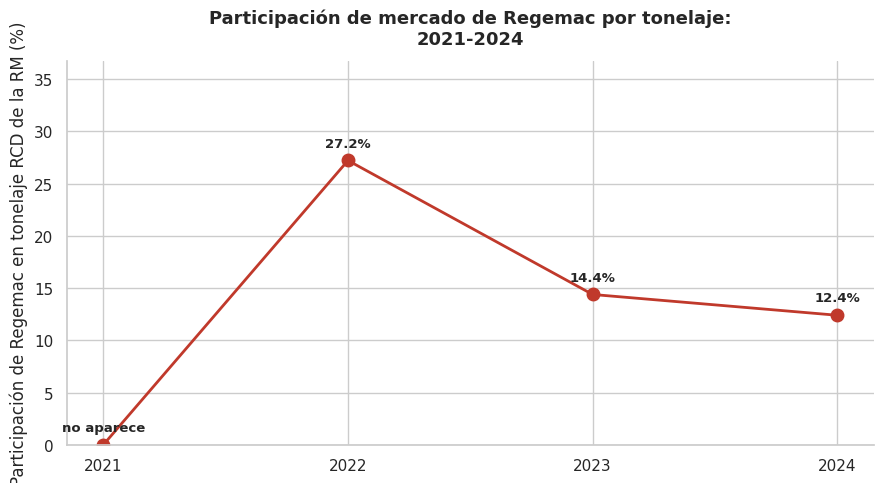

 año  declaraciones  ton_regemac  share_regemac_%
2021             46        0.000         0.000000
2022            271   117835.321        27.206503
2023            211    60303.892        14.384964
2024           2345   118456.781        12.395768


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_resumen_anual['año'], df_resumen_anual['share_regemac_%'], marker='o', markersize=9,
        color='#c0392b', linewidth=2)
for x, y, n in zip(df_resumen_anual['año'], df_resumen_anual['share_regemac_%'], df_resumen_anual['declaraciones']):
    presente = "aparece" if y > 0 else "no aparece"
    ax.annotate(f"{y:.1f}%" if y > 0 else "no aparece", (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9.5, fontweight='bold')
ax.set_xticks(df_resumen_anual['año'])
ax.set_ylim(0, max(df_resumen_anual['share_regemac_%']) * 1.35)
ax.set_ylabel("Participación de Regemac en tonelaje RCD de la RM (%)")
ax.set_title(wrap_title("Participación de mercado de Regemac por tonelaje: 2021-2024", 55), fontsize=13, fontweight='bold', pad=12)
sns.despine()
plt.tight_layout()
plt.show()

print(df_resumen_anual[['año', 'declaraciones', 'ton_regemac', 'share_regemac_%']].to_string(index=False))

**Regemac ya aparece en la base RETC en los tres años anteriores disponibles (2022 y 2023) y no aparece en 2021** (probablemente no declaró ese año, o lo hizo bajo una razón social no capturada por el filtro de texto usado). La participación por tonelaje varía bastante: ~27% (2022, con solo 22 declaraciones — muestra chica y volátil), ~14% (2023, con solo 8 declaraciones) y ~12% (2024, con una muestra mucho más grande y confiable). La lectura más razonable es que **la cifra de 2024 es la más representativa** (mayor cantidad de observaciones, reporte mensual granular) y que el aparente "descenso" 2022→2024 refleja en gran parte el tamaño muestral minúsculo de los años anteriores (8-22 declaraciones) más que una pérdida real de mercado — no hay base suficiente para afirmar una tendencia a la baja. Para el Pilar 3 esto sugiere usar el 12,4% de 2024 como el número de referencia, mencionando el rango 12-27% como banda de incertidumbre histórica más que como una serie confiable.

---
## 6. Tratamiento declarado: primario, secundario y terciario

Se mantiene el desglose original por nivel de tratamiento (primario/secundario/terciario), comparando la Región Metropolitana contra el total nacional. Esto alimenta directamente el diagrama de flujo (Sankey) de la sección 6.

In [ ]:
tratamientos = df_rcd_rm['tratamiento_n1_name'].value_counts()
print("Tratamiento primario del residuo declarado en la RM:")
print(tratamientos)

tratamientos2 = df_rcd_rm['tratamiento_n2_name'].value_counts()
print("\nTratamiento secundario del residuo declarado en la RM:")
print(tratamientos2)

tratamientos3 = df_rcd_rm['tratamiento_n3_name'].value_counts()
print("\nTratamiento terciario del residuo declarado en la RM:")
print(tratamientos3)

Tratamiento primario del residuo declarado en la RM:
tratamiento_n1_name
Eliminación                   1253
Valorización                   782
Recepción y Almacenamiento     310
Name: count, dtype: int64

Tratamiento secundario del residuo declarado en la RM:
tratamiento_n2_name
Disposición final                 1202
Reciclaje                          727
Pretratamiento (I.R.A.R.)          309
Pretratamiento                      26
Recuperación de energía             20
Preparación para reutilización      12
Aplicación al Suelo                 10
Name: count, dtype: int64

Tratamiento terciario del residuo declarado en la RM:
tratamiento_n3_name
Reciclaje de metales                                                        543
Sitio de Escombros de la Construcción                                       535
Relleno sanitario                                                           358
Vertedero                                                                   172
Pretratamiento de Metales 

In [ ]:
tratamientos_total = df_rcd['tratamiento_n1_name'].value_counts()
print("Tratamiento primario del residuo declarado (nacional):")
print(tratamientos_total)

tratamientos_total2 = df_rcd['tratamiento_n2_name'].value_counts()
print("\nTratamiento secundario del residuo declarado (nacional):")
print(tratamientos_total2)

tratamientos_total3 = df_rcd['tratamiento_n3_name'].value_counts()
print("\nTratamiento terciario del residuo declarado (nacional):")
print(tratamientos_total3)

Tratamiento primario del residuo declarado (nacional):
tratamiento_n1_name
Eliminación                   2652
Valorización                  1336
Recepción y Almacenamiento     473
Name: count, dtype: int64

Tratamiento secundario del residuo declarado (nacional):
tratamiento_n2_name
Disposición final                 2592
Reciclaje                         1220
Pretratamiento (I.R.A.R.)          470
Aplicación al Suelo                 58
Pretratamiento                      27
Recuperación de energía             20
Preparación para reutilización      17
Name: count, dtype: int64

Tratamiento terciario del residuo declarado (nacional):
tratamiento_n3_name
Sitio de Escombros de la Construcción                                       1082
Relleno sanitario                                                            829
Reciclaje de metales                                                         781
Vertedero                                                                    398
Pretratamiento d

---
## 7. Destino de los RCD: ¿cuánto se valoriza realmente?

El gráfico de dona original mostraba el tratamiento secundario por número de declaraciones, pero con siete categorías el `autopct` de matplotlib terminaba superponiendo los porcentajes de las porciones pequeñas. Se corrige ocultando el porcentaje in-situ cuando la porción es menor a 3% (queda igual disponible en la leyenda) y moviendo la leyenda fuera del círculo.

Además, se agrega la vista que realmente importa para el caso de negocio: **el mismo destino, pero ponderado por tonelaje**. Es la pregunta que Regemac necesita responder para dimensionar el "costo de oportunidad de la fosa" (Pilar 3): de todo lo que *pesa*, ¿cuánto se está desviando de la disposición final hoy?

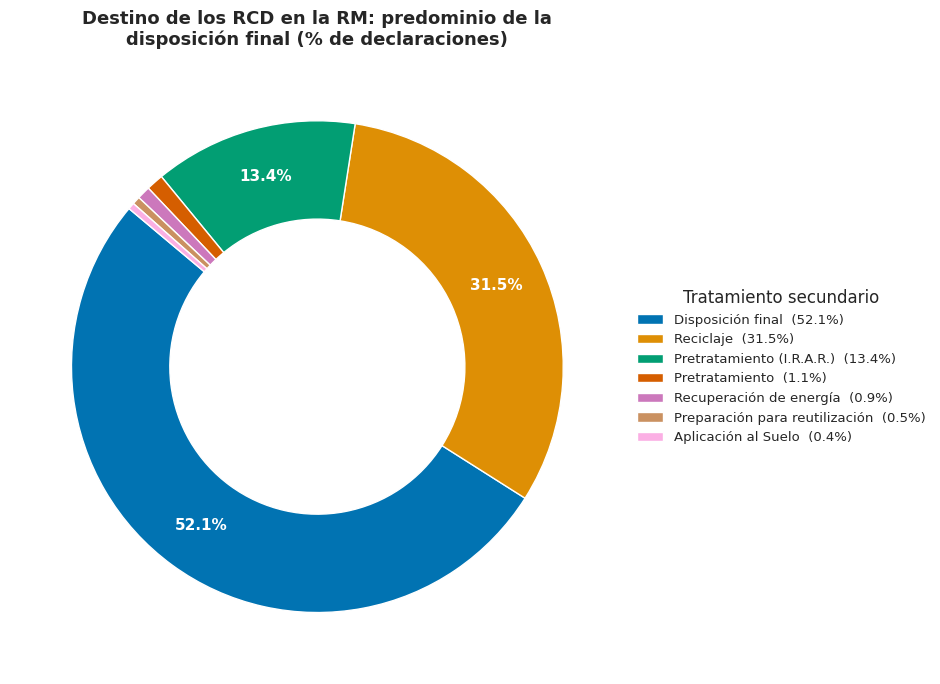

In [ ]:
tratamientos_n2 = df_rcd_rm['tratamiento_n2_name'].value_counts()

def autopct_con_umbral(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

fig, ax = plt.subplots(figsize=(9, 7))
colores = sns.color_palette(PALETA, len(tratamientos_n2))
wedges, texts, autotexts = ax.pie(
    tratamientos_n2.values, autopct=autopct_con_umbral, startangle=140, colors=colores, pctdistance=0.8,
    textprops=dict(color="white", fontsize=11, fontweight='bold'),
    wedgeprops=dict(width=0.4, edgecolor='white'))

etiquetas_leyenda = [f"{nombre}  ({v / tratamientos_n2.sum() * 100:.1f}%)" for nombre, v in tratamientos_n2.items()]
ax.legend(wedges, etiquetas_leyenda, title="Tratamiento secundario", loc='center left',
          bbox_to_anchor=(1.0, 0.5), fontsize=9.5, frameon=False)
ax.set_title(wrap_title("Destino de los RCD en la RM: predominio de la disposición final (% de declaraciones)", 46),
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

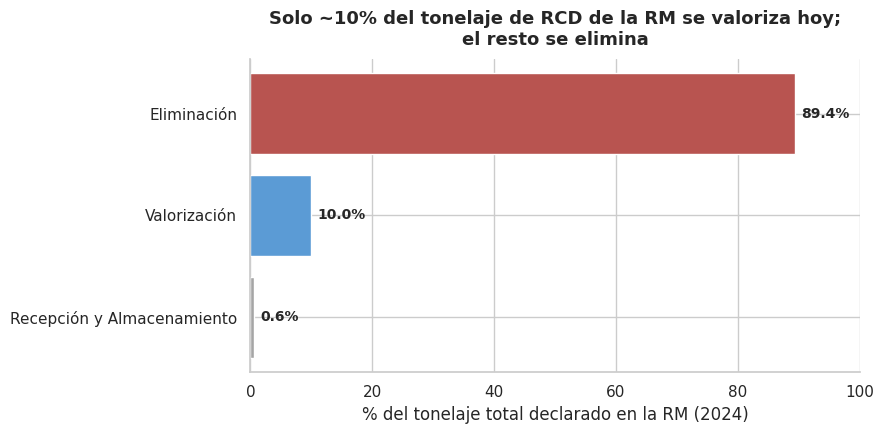

In [ ]:
ton_n1 = df_rcd_rm.groupby('tratamiento_n1_name')['cantidad_toneladas'].sum().sort_values(ascending=False)
pct_n1 = ton_n1 / ton_n1.sum() * 100

colores_n1 = {'Eliminación': '#B85450', 'Valorización': '#5B9BD5', 'Recepción y Almacenamiento': '#A5A5A5'}
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(pct_n1.index[::-1], pct_n1.values[::-1],
               color=[colores_n1.get(x, '#888888') for x in pct_n1.index[::-1]])
for b, v in zip(bars, pct_n1.values[::-1]):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, 100)
ax.set_title(wrap_title("Solo ~10% del tonelaje de RCD de la RM se valoriza hoy; el resto se elimina", 55),
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel("% del tonelaje total declarado en la RM (2024)")
sns.despine()
plt.tight_layout()
plt.show()

La brecha entre ambas vistas es la evidencia más directa del problema que Regemac busca resolver: por **número de declaraciones**, la disposición final concentra ~52%; por **tonelaje**, sube a ~89%. Es decir, el material que efectivamente se valoriza tiende a ser liviano y declarado en muchos lotes pequeños (metales, sobre todo), mientras que el grueso del peso —hormigón, tierra, mezclas inertes— hoy va casi íntegramente a eliminación. Ese es exactamente el volumen que una planta de segregación mecanizada podría empezar a desviar.

---
## 8. Estructura de mercado en la Región Metropolitana

### 8.1 Concentración (IHH): una corrección metodológica

El cálculo original del Índice de Herfindahl-Hirschman usaba la **participación por número de declaraciones** de cada destinatario. Es una aproximación razonable pero sesgada: una empresa puede aparecer en muchas declaraciones de lotes pequeños y aun así mover poco tonelaje real (o viceversa). Como *market share* la métrica correcta es la **participación por tonelaje recibido**, así que se calculan ambas versiones para dejar en evidencia la diferencia.

In [ ]:
# Versión original: participación por N° de declaraciones
participaciones_conteo = df_rcd_rm['trazabilidad__razon_social'].value_counts(normalize=True)
ihh_conteo = ((participaciones_conteo * 100) ** 2).sum()

# Versión corregida: participación por tonelaje recibido (más representativa de "cuota de mercado")
tonelaje_actor = df_rcd_rm.groupby('trazabilidad__razon_social')['cantidad_toneladas'].sum()
participaciones_ton = tonelaje_actor / tonelaje_actor.sum()
ihh_tonelaje = ((participaciones_ton * 100) ** 2).sum()

print(f"IHH por N° de declaraciones: {ihh_conteo:,.0f}")
print(f"IHH por tonelaje recibido:   {ihh_tonelaje:,.0f}")
print("(Referencia HHI: <1500 mercado no concentrado · 1500-2500 moderadamente concentrado · >2500 altamente concentrado)")

nombre_regemac = 'REGENERADORA DE MATERIALES DE CONSTRUCCION S A'
if nombre_regemac in tonelaje_actor.index:
    ranking = list(tonelaje_actor.sort_values(ascending=False).index).index(nombre_regemac) + 1
    print(f"\nRegemac (declarado como '{nombre_regemac}') aparece en la propia base RETC:")
    print(f"  Participación por tonelaje: {participaciones_ton[nombre_regemac] * 100:.2f}%  (ranking #{ranking} de {len(tonelaje_actor)} destinatarios en la RM)")
    print(f"  Participación por N° de declaraciones: {participaciones_conteo[nombre_regemac] * 100:.2f}%")

IHH por N° de declaraciones: 510
IHH por tonelaje recibido:   1,458
(Referencia HHI: <1500 mercado no concentrado · 1500-2500 moderadamente concentrado · >2500 altamente concentrado)

Regemac (declarado como 'REGENERADORA DE MATERIALES DE CONSTRUCCION S A') aparece en la propia base RETC:
  Participación por tonelaje: 12.40%  (ranking #4 de 88 destinatarios en la RM)
  Participación por N° de declaraciones: 5.44%


**Hallazgo relevante:** Regemac ya figura en la base RETC como destinatario final bajo la razón social *"Regeneradora de Materiales de Construcción S.A."*, con una participación de mercado no trivial en la RM. Esto es un dato duro y verificable para la sección de "descripción cuantitativa de la organización" que pide la pauta (punto 1 de la guía), y para contrastar contra la cifra de ~230 obras mensuales que reporta la empresa.

### 8.2 ¿Quién concentra el mercado? (por tonelaje, con Regemac destacado)

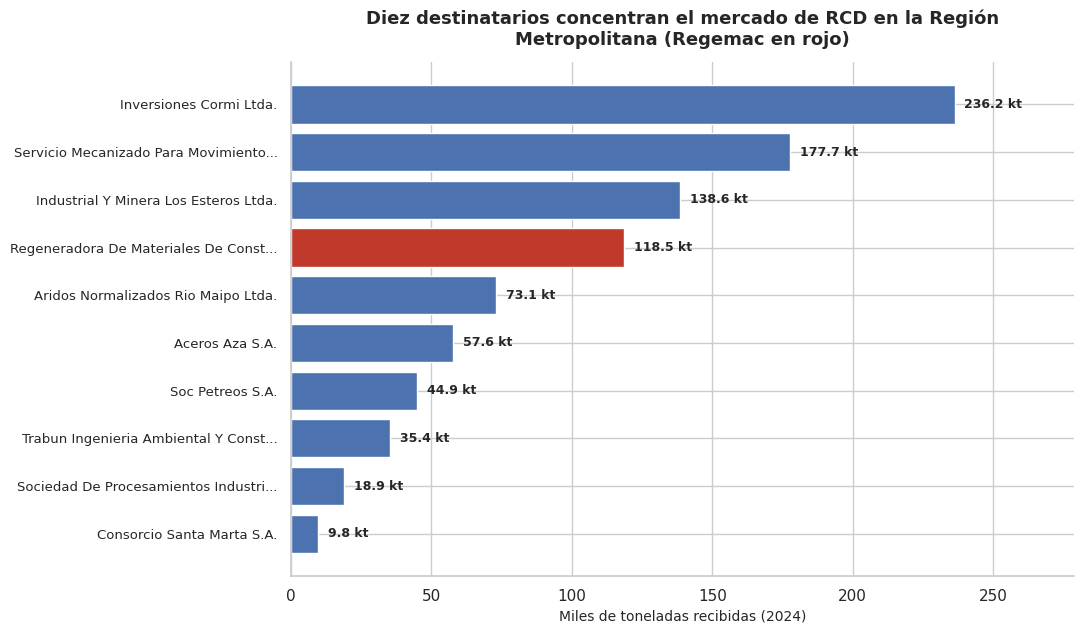

In [ ]:
top_actores = tonelaje_actor.sort_values(ascending=False).head(10)

def nombre_corto_empresa(razon_social, max_len=38):
    n = razon_social.title()
    reemplazos = {' S A': ' S.A.', ' Sa': ' S.A.', ' Spa': ' SpA', ' Ltda': ' Ltda.', ' Limitada': ' Ltda.'}
    for k, v in reemplazos.items():
        if n.endswith(k):
            n = n[: -len(k)] + v
    return n if len(n) <= max_len else n[: max_len - 3] + "..."

labels_empresas = [nombre_corto_empresa(x) for x in top_actores.index]
es_regemac = [nombre_regemac in x for x in top_actores.index]
colores_barras = ['#c0392b' if r else '#4C72B0' for r in es_regemac]

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(labels_empresas[::-1], top_actores.values[::-1] / 1000, color=colores_barras[::-1])
for b, v in zip(bars, top_actores.values[::-1] / 1000):
    ax.text(v + top_actores.values.max() / 1000 * 0.015, b.get_y() + b.get_height() / 2,
            f"{v:.1f} kt", va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, top_actores.values.max() / 1000 * 1.18)
ax.set_title(wrap_title("Diez destinatarios concentran el mercado de RCD en la Región Metropolitana (Regemac en rojo)", 60),
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Miles de toneladas recibidas (2024)", fontsize=10)
ax.tick_params(axis='y', labelsize=9.5)
sns.despine()
plt.tight_layout()
plt.show()

---
## 9. Flujo de tratamiento: de primario a terciario

El diagrama de Sankey original llegaba solo hasta el tratamiento secundario. Se agrega el **nivel terciario** (por ejemplo, dentro de "Disposición final": relleno sanitario vs. vertedero vs. sitio de escombros; dentro de "Reciclaje": de metales, de plásticos, de papel, etc.), que es literalmente el detalle operativo que Regemac necesita para decidir a qué proceso específico destinar cada fracción segregada.

Con 30 categorías de nivel terciario el diagrama se vuelve ilegible, así que las que tienen muy pocos casos (menos de 12 declaraciones a nivel nacional) se agrupan en "Otros procesos" — se puede bajar ese umbral si se quiere más detalle a costa de legibilidad.

In [ ]:
import plotly.graph_objects as go

df_flujo = df_rcd[['tratamiento_n1_name', 'tratamiento_n2_name', 'tratamiento_n3_name']].dropna().copy()

UMBRAL_MIN_CASOS = 12
frecuencia_n3 = df_flujo['tratamiento_n3_name'].value_counts()
n3_frecuentes = set(frecuencia_n3[frecuencia_n3 >= UMBRAL_MIN_CASOS].index)
df_flujo['n3_agrupado'] = df_flujo['tratamiento_n3_name'].apply(
    lambda x: x if x in n3_frecuentes else f'Otros procesos (< {UMBRAL_MIN_CASOS} casos c/u)')

n1_vals = sorted(df_flujo['tratamiento_n1_name'].unique().tolist())
n2_vals = sorted(df_flujo['tratamiento_n2_name'].unique().tolist())
n3_vals = df_flujo['n3_agrupado'].value_counts().index.tolist()

nodos_clave = [f"L1·{x}" for x in n1_vals] + [f"L2·{x}" for x in n2_vals] + [f"L3·{x}" for x in n3_vals]
indice_nodo = {label: i for i, label in enumerate(nodos_clave)}
etiquetas_visibles = n1_vals + n2_vals + n3_vals

color_n1, color_n2, color_n3 = '#2c3e50', '#2980b9', '#16a085'
colores_nodo = [color_n1] * len(n1_vals) + [color_n2] * len(n2_vals) + [color_n3] * len(n3_vals)
pos_x = [0.01] * len(n1_vals) + [0.5] * len(n2_vals) + [0.99] * len(n3_vals)

enlaces_12 = df_flujo.groupby(['tratamiento_n1_name', 'tratamiento_n2_name']).size().reset_index(name='value')
enlaces_23 = df_flujo.groupby(['tratamiento_n2_name', 'n3_agrupado']).size().reset_index(name='value')

paleta_n1 = {'Valorización': 'rgba(41,128,185,0.45)', 'Eliminación': 'rgba(192,57,43,0.4)',
             'Recepción y Almacenamiento': 'rgba(127,140,141,0.4)'}
sources, targets, values, colores_enlace = [], [], [], []
for _, row in enlaces_12.iterrows():
    sources.append(indice_nodo[f"L1·{row['tratamiento_n1_name']}"])
    targets.append(indice_nodo[f"L2·{row['tratamiento_n2_name']}"])
    values.append(row['value'])
    colores_enlace.append(paleta_n1.get(row['tratamiento_n1_name'], 'rgba(150,150,150,0.35)'))
for _, row in enlaces_23.iterrows():
    sources.append(indice_nodo[f"L2·{row['tratamiento_n2_name']}"])
    targets.append(indice_nodo[f"L3·{row['n3_agrupado']}"])
    values.append(row['value'])
    colores_enlace.append('rgba(22,160,133,0.35)')

fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(pad=14, thickness=16, line=dict(color="white", width=0.5),
              label=etiquetas_visibles, color=colores_nodo, x=pos_x),
    link=dict(source=sources, target=targets, value=values, color=colores_enlace)
)])
fig.update_layout(
    title_text="Flujo de tratamiento de RCD 2024: primario → secundario → terciario (Chile)",
    font=dict(size=12, family="Arial"), width=1150, height=750, margin=dict(l=10, r=10, t=60, b=10))
fig.show()

> Si al ejecutar esto en Colab la imagen no se ve o se ve en blanco al exportar a PDF/HTML estático, es un tema de `kaleido`/Chrome para renderizado offline: en Colab normal `fig.show()` funciona directo en el navegador sin necesitar exportar nada.

---
## 10. Mapa geográfico de destinatarios en la Región Metropolitana

Mejoras sobre el mapa original:

1. **Fondo con la silueta de las comunas de la Región Metropolitana**, para que el gráfico se reconozca de inmediato como Santiago sin depender de ningún mapa base descargado de internet. Se probó primero con `contextily`/OpenStreetMap, pero en Colab real ese proveedor bloquea las descargas desde IPs de centros de datos (devuelve una imagen de "Access blocked" en vez de un error), lo que hacía que el mapa fallara de forma silenciosa y solo a veces. La silueta de comunas es **100% offline y determinista**: se calcula una sola vez a partir de un GeoJSON público de límites comunales, se simplifica y se embebe directamente en esta celda, así que el resultado es siempre el mismo sin importar la conectividad. Se usa un gris muy claro para que no compita visualmente con los puntos de colores.
2. **Filtro de calidad de datos**: se excluyen los ~164 registros marcados como región RM cuyas coordenadas caen fuera de la Región Metropolitana (ver nota de la sección 2) — de lo contrario el mapa termina dominado por un par de puntos en el sur de Chile y todo Santiago queda apretado en una esquina.

También se agrega el tonelaje como tamaño del punto (ya estaba) pero agregado **por establecimiento** (antes se graficaba una fila por declaración, lo que sobrepone muchos puntos exactamente en las mismas coordenadas y no se nota en el gráfico).

In [ ]:
# Siluetas de las 49 comunas de la Región Metropolitana (excluidas 3 muy rurales/lejanas:
# San José de Maipo, San Pedro y Alhué), simplificadas a partir de un GeoJSON público
# (fuente: github.com/caracena/chile-geojson) y embebidas aquí para que el mapa
# funcione siempre igual, sin depender de internet en el momento de ejecutar la celda.
import json
import numpy as np
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

COMUNAS_RM_POLIGONOS = json.loads('''{"San Joaquín":[[[-70.6246,-33.47],[-70.6113,-33.5131],[-70.6366,-33.5187],[-70.6419,-33.4769],[-70.6246,-33.47]]],"San Miguel":[[[-70.6366,-33.5187],[-70.6712,-33.5107],[-70.6551,-33.4767],[-70.6419,-33.4769],[-70.6366,-33.5187]]],"San Ramón":[[[-70.6366,-33.5187],[-70.631,-33.5581],[-70.6547,-33.555],[-70.6446,-33.5174],[-70.6366,-33.5187]]],"Independencia":[[[-70.6582,-33.3991],[-70.6501,-33.4177],[-70.6516,-33.4322],[-70.6714,-33.4265],[-70.6819,-33.403],[-70.6582,-33.3991]]],"La Cisterna":[[[-70.6529,-33.5476],[-70.6858,-33.539],[-70.6712,-33.5107],[-70.6446,-33.5174],[-70.6529,-33.5476]]],"Peñalolén":[[[-70.59,-33.5102],[-70.5723,-33.459],[-70.5312,-33.4654],[-70.5295,-33.4591],[-70.4869,-33.4618],[-70.472,-33.4754],[-70.4611,-33.4761],[-70.4379,-33.4902],[-70.4508,-33.4958],[-70.4667,-33.4921],[-70.4857,-33.5016],[-70.4992,-33.4978],[-70.5417,-33.5125],[-70.59,-33.5102]]],"Providencia":[[[-70.5844,-33.4318],[-70.5928,-33.4478],[-70.6315,-33.4498],[-70.6362,-33.4308],[-70.6168,-33.4103],[-70.6059,-33.4093],[-70.6079,-33.4155],[-70.5844,-33.4318]]],"La Reina":[[[-70.4869,-33.4618],[-70.562,-33.4625],[-70.5723,-33.459],[-70.5736,-33.4379],[-70.5844,-33.4318],[-70.5391,-33.4289],[-70.5379,-33.4334],[-70.5095,-33.4357],[-70.4869,-33.4618]]],"Calera de Tango":[[[-70.8025,-33.6684],[-70.8152,-33.6428],[-70.8363,-33.6625],[-70.8671,-33.6506],[-70.8457,-33.6339],[-70.8168,-33.5959],[-70.8086,-33.5937],[-70.7981,-33.5733],[-70.7887,-33.5783],[-70.7788,-33.5692],[-70.7584,-33.5742],[-70.7435,-33.595],[-70.7544,-33.6036],[-70.7467,-33.6175],[-70.7569,-33.6212],[-70.7356,-33.6464],[-70.7379,-33.6564],[-70.7492,-33.6644],[-70.7841,-33.6533],[-70.8025,-33.6684]]],"Colina":[[[-70.792,-33.173],[-70.7565,-33.1796],[-70.7344,-33.1644],[-70.7592,-33.1261],[-70.7543,-33.1182],[-70.7598,-33.1041],[-70.747,-33.0689],[-70.7669,-33.0554],[-70.7502,-33.0122],[-70.7704,-32.9837],[-70.72,-32.953],[-70.7078,-32.9605],[-70.6918,-32.9554],[-70.674,-32.9597],[-70.6367,-32.9475],[-70.6136,-32.9515],[-70.6038,-32.9423],[-70.5943,-32.9486],[-70.5976,-32.953],[-70.5919,-32.9594],[-70.5923,-32.97],[-70.565,-32.9907],[-70.5469,-33.0142],[-70.5531,-33.0348],[-70.5272,-33.0524],[-70.5192,-33.0786],[-70.5091,-33.0892],[-70.4823,-33.0811],[-70.4777,-33.0685],[-70.4659,-33.0629],[-70.4511,-33.0381],[-70.4347,-33.0214],[-70.4272,-33.021],[-70.3995,-33.0342],[-70.3967,-33.051],[-70.4066,-33.066],[-70.3864,-33.0829],[-70.3886,-33.089],[-70.3736,-33.1057],[-70.398,-33.1217],[-70.4283,-33.1304],[-70.4448,-33.1597],[-70.4623,-33.1776],[-70.4594,-33.1888],[-70.4673,-33.1953],[-70.465,-33.2033],[-70.4732,-33.2196],[-70.5092,-33.2191],[-70.5249,-33.2391],[-70.5583,-33.2419],[-70.5599,-33.2515],[-70.5738,-33.2664],[-70.5745,-33.2894],[-70.6046,-33.3107],[-70.5942,-33.3356],[-70.6195,-33.3424],[-70.6451,-33.3419],[-70.6587,-33.3285],[-70.6813,-33.331],[-70.7073,-33.3189],[-70.7183,-33.3259],[-70.783,-33.1816],[-70.792,-33.173]]],"Santiago":[[[-70.6782,-33.4269],[-70.6354,-33.4359],[-70.6246,-33.47],[-70.6418,-33.4769],[-70.6809,-33.4785],[-70.672,-33.4765],[-70.6729,-33.4706],[-70.6801,-33.4707],[-70.6796,-33.4439],[-70.6918,-33.4445],[-70.6916,-33.4395],[-70.6801,-33.4385],[-70.6782,-33.4269]]],"Lampa":[[[-70.792,-33.173],[-70.783,-33.1816],[-70.7188,-33.3246],[-70.7935,-33.3413],[-70.7979,-33.3385],[-70.8041,-33.3516],[-70.8208,-33.3627],[-70.8392,-33.3853],[-70.8629,-33.3757],[-70.8925,-33.3755],[-70.9103,-33.3684],[-70.9467,-33.3849],[-70.9681,-33.3759],[-70.9854,-33.3596],[-70.9865,-33.3497],[-71.0035,-33.3291],[-71.0017,-33.3087],[-70.9685,-33.29],[-71.0006,-33.2232],[-70.9934,-33.1777],[-70.9817,-33.1723],[-70.9633,-33.1775],[-70.9533,-33.1725],[-70.9298,-33.1868],[-70.8929,-33.1811],[-70.8898,-33.188],[-70.8946,-33.2109],[-70.8862,-33.2147],[-70.8878,-33.2239],[-70.883,-33.2289],[-70.8668,-33.2258],[-70.85,-33.1978],[-70.8504,-33.1879],[-70.8572,-33.1814],[-70.8353,-33.1797],[-70.8259,-33.1849],[-70.8076,-33.1718],[-70.792,-33.173]]],"Pirque":[[[-70.4338,-33.8536],[-70.4399,-33.8506],[-70.4503,-33.8584],[-70.4731,-33.8627],[-70.4752,-33.8484],[-70.4872,-33.8305],[-70.5251,-33.8322],[-70.5368,-33.8097],[-70.5358,-33.8002],[-70.5596,-33.7846],[-70.5959,-33.781],[-70.5991,-33.7602],[-70.6144,-33.7385],[-70.616,-33.7226],[-70.6273,-33.7072],[-70.6453,-33.6968],[-70.6559,-33.6757],[-70.6517,-33.6644],[-70.6348,-33.6535],[-70.6312,-33.6428],[-70.5916,-33.6382],[-70.5647,-33.6204],[-70.5122,-33.6147],[-70.4792,-33.5899],[-70.4609,-33.5911],[-70.4614,-33.5815],[-70.4438,-33.5787],[-70.4392,-33.6152],[-70.4278,-33.6201],[-70.4212,-33.6368],[-70.4072,-33.6466],[-70.4334,-33.6646],[-70.4317,-33.6735],[-70.4409,-33.6834],[-70.4339,-33.6949],[-70.4092,-33.7035],[-70.4005,-33.7119],[-70.4046,-33.7312],[-70.4,-33.7493],[-70.4083,-33.7745],[-70.403,-33.804],[-70.4078,-33.8319],[-70.4338,-33.8536]]],"Puente Alto":[[[-70.4875,-33.5434],[-70.4888,-33.5591],[-70.5005,-33.5732],[-70.4954,-33.5999],[-70.5011,-33.6028],[-70.4984,-33.6079],[-70.5191,-33.6165],[-70.5664,-33.621],[-70.5916,-33.6382],[-70.6312,-33.6428],[-70.6269,-33.6047],[-70.606,-33.602],[-70.6113,-33.5706],[-70.5837,-33.5695],[-70.5845,-33.5656],[-70.5574,-33.5608],[-70.5683,-33.5477],[-70.5471,-33.552],[-70.5255,-33.5434],[-70.4875,-33.5434]]],"Huechuraba":[[[-70.6893,-33.3662],[-70.6934,-33.3516],[-70.6782,-33.3297],[-70.6587,-33.3285],[-70.6385,-33.3428],[-70.5961,-33.3371],[-70.5825,-33.351],[-70.6011,-33.3627],[-70.5973,-33.3658],[-70.6015,-33.3885],[-70.6106,-33.405],[-70.6453,-33.3808],[-70.6893,-33.3662]]],"San Bernardo":[[[-70.7667,-33.5722],[-70.7264,-33.5239],[-70.6854,-33.5391],[-70.7008,-33.573],[-70.6632,-33.5852],[-70.6706,-33.6075],[-70.6432,-33.6099],[-70.6431,-33.6272],[-70.6287,-33.6278],[-70.6312,-33.6428],[-70.6734,-33.6601],[-70.71,-33.6655],[-70.7259,-33.6931],[-70.7681,-33.7072],[-70.7957,-33.7308],[-70.8106,-33.7367],[-70.8144,-33.751],[-70.8211,-33.7542],[-70.8261,-33.7486],[-70.8205,-33.737],[-70.8244,-33.721],[-70.8064,-33.7202],[-70.7918,-33.6981],[-70.8025,-33.6684],[-70.7841,-33.6533],[-70.7492,-33.6644],[-70.7379,-33.6564],[-70.7356,-33.6464],[-70.7569,-33.6212],[-70.7467,-33.6175],[-70.7544,-33.6036],[-70.7435,-33.595],[-70.7564,-33.5757],[-70.7667,-33.5722]]],"Curacaví":[[[-70.9975,-33.1984],[-71.0006,-33.2232],[-70.9685,-33.29],[-70.9994,-33.3058],[-71.0035,-33.3291],[-70.9865,-33.3497],[-70.9854,-33.3596],[-70.9681,-33.3759],[-70.9467,-33.3849],[-70.952,-33.3994],[-70.9483,-33.4318],[-70.9549,-33.448],[-70.9481,-33.4696],[-70.9293,-33.4772],[-70.9214,-33.4883],[-70.93,-33.5021],[-70.9197,-33.5113],[-70.9293,-33.5463],[-70.9484,-33.5606],[-70.9609,-33.5477],[-71.0134,-33.5402],[-71.0362,-33.5216],[-71.044,-33.5043],[-71.0626,-33.4944],[-71.061,-33.4788],[-71.0736,-33.4683],[-71.066,-33.4597],[-71.0592,-33.4307],[-71.0904,-33.4447],[-71.1091,-33.4415],[-71.1488,-33.4498],[-71.166,-33.4456],[-71.1865,-33.4521],[-71.1937,-33.4407],[-71.2296,-33.4337],[-71.2513,-33.4127],[-71.2772,-33.4029],[-71.266,-33.3871],[-71.223,-33.3732],[-71.2143,-33.3555],[-71.2131,-33.3317],[-71.2062,-33.3312],[-71.205,-33.321],[-71.196,-33.3117],[-71.2104,-33.3027],[-71.2144,-33.2857],[-71.2267,-33.2694],[-71.2197,-33.2595],[-71.2257,-33.2465],[-71.2153,-33.2344],[-71.1894,-33.2268],[-71.1708,-33.2309],[-71.1627,-33.2257],[-71.1405,-33.2378],[-71.1205,-33.2312],[-71.1108,-33.2209],[-71.0941,-33.2197],[-71.0721,-33.2303],[-71.0601,-33.2249],[-71.0569,-33.2045],[-71.0468,-33.2099],[-71.0385,-33.2076],[-71.027,-33.2165],[-71.0269,-33.2023],[-70.9975,-33.1984]]],"María Pinto":[[[-71.0134,-33.5402],[-71.0315,-33.5515],[-71.0592,-33.5561],[-71.1073,-33.5478],[-71.1158,-33.5547],[-71.1279,-33.5485],[-71.1801,-33.5543],[-71.2092,-33.5415],[-71.2309,-33.5629],[-71.2387,-33.5618],[-71.2342,-33.5659],[-71.2434,-33.5666],[-71.2442,-33.5742],[-71.2533,-33.577],[-71.2523,-33.5828],[-71.2757,-33.5806],[-71.2888,-33.5885],[-71.3213,-33.5872],[-71.3291,-33.5835],[-71.3319,-33.5358],[-71.3509,-33.5287],[-71.3484,-33.5086],[-71.3532,-33.4926],[-71.3395,-33.476],[-71.3419,-33.464],[-71.3362,-33.4559],[-71.3433,-33.4157],[-71.3311,-33.4076],[-71.2978,-33.4133],[-71.2817,-33.4105],[-71.2764,-33.4043],[-71.2513,-33.4127],[-71.2296,-33.4337],[-71.1937,-33.4407],[-71.1865,-33.4521],[-71.166,-33.4456],[-71.1488,-33.4498],[-71.1091,-33.4415],[-71.0904,-33.4447],[-71.0592,-33.4307],[-71.066,-33.4597],[-71.0736,-33.4683],[-71.061,-33.4788],[-71.0637,-33.493],[-71.044,-33.5043],[-71.0362,-33.5216],[-71.0134,-33.5402]]],"Cerrillos":[[[-70.6857,-33.4781],[-70.7067,-33.5312],[-70.7264,-33.5239],[-70.7185,-33.5141],[-70.7233,-33.51],[-70.7401,-33.5101],[-70.7315,-33.4949],[-70.7315,-33.4828],[-70.7247,-33.4827],[-70.7224,-33.4734],[-70.7119,-33.4827],[-70.6857,-33.4781]]],"Cerro Navia":[[[-70.7215,-33.4366],[-70.7409,-33.4364],[-70.7408,-33.4299],[-70.7757,-33.4245],[-70.7823,-33.4137],[-70.7225,-33.4117],[-70.7159,-33.4151],[-70.7215,-33.4366]]],"Vitacura":[[[-70.5177,-33.3726],[-70.5541,-33.3923],[-70.6145,-33.4092],[-70.6015,-33.3885],[-70.5973,-33.3658],[-70.6011,-33.3627],[-70.5825,-33.351],[-70.5503,-33.3593],[-70.5412,-33.3701],[-70.5177,-33.3726]]],"Conchalí":[[[-70.6581,-33.3991],[-70.6819,-33.403],[-70.7003,-33.3662],[-70.6568,-33.3765],[-70.6581,-33.3991]]],"El Bosque":[[[-70.6632,-33.5852],[-70.7008,-33.573],[-70.6854,-33.5391],[-70.6532,-33.5488],[-70.6632,-33.5852]]],"Estación Central":[[[-70.672,-33.4765],[-70.7119,-33.4827],[-70.7338,-33.4696],[-70.7313,-33.4549],[-70.7104,-33.4583],[-70.7056,-33.4572],[-70.7071,-33.4488],[-70.6796,-33.4439],[-70.6801,-33.4707],[-70.6729,-33.4706],[-70.672,-33.4765]]],"La Florida":[[[-70.4379,-33.4922],[-70.439,-33.5002],[-70.4639,-33.5163],[-70.4875,-33.5434],[-70.5255,-33.5434],[-70.5471,-33.552],[-70.5683,-33.5477],[-70.5574,-33.5608],[-70.5845,-33.5656],[-70.5837,-33.5695],[-70.6113,-33.5706],[-70.6137,-33.5084],[-70.5417,-33.5125],[-70.4992,-33.4978],[-70.4857,-33.5016],[-70.4667,-33.4921],[-70.4508,-33.4958],[-70.4379,-33.4922]]],"La Granja":[[[-70.6366,-33.5187],[-70.6113,-33.5131],[-70.6122,-33.5556],[-70.6307,-33.5598],[-70.6366,-33.5187]]],"La Pintana":[[[-70.6549,-33.555],[-70.6122,-33.5556],[-70.606,-33.602],[-70.6269,-33.6047],[-70.6287,-33.6278],[-70.6431,-33.6272],[-70.6432,-33.6099],[-70.6706,-33.6075],[-70.6549,-33.555]]],"Las Condes":[[[-70.5434,-33.3881],[-70.4928,-33.3646],[-70.4785,-33.3663],[-70.4755,-33.3688],[-70.4836,-33.3792],[-70.4771,-33.3943],[-70.4545,-33.3974],[-70.4535,-33.4165],[-70.435,-33.4272],[-70.4286,-33.4517],[-70.4392,-33.4866],[-70.475,-33.4736],[-70.5095,-33.4357],[-70.5379,-33.4334],[-70.5391,-33.4289],[-70.5844,-33.4318],[-70.6079,-33.4155],[-70.6059,-33.4093],[-70.5434,-33.3881]]],"Lo Barnechea":[[[-70.4344,-33.481],[-70.4354,-33.4681],[-70.4281,-33.4582],[-70.434,-33.4288],[-70.4535,-33.4165],[-70.4545,-33.3974],[-70.4771,-33.3943],[-70.4836,-33.3792],[-70.4765,-33.3674],[-70.4928,-33.3646],[-70.5176,-33.3727],[-70.5412,-33.3701],[-70.5503,-33.3593],[-70.5734,-33.3555],[-70.5881,-33.3467],[-70.6046,-33.3107],[-70.5745,-33.2894],[-70.5738,-33.2664],[-70.5599,-33.2515],[-70.5583,-33.2419],[-70.5249,-33.2391],[-70.5156,-33.2315],[-70.513,-33.2202],[-70.4706,-33.2172],[-70.4673,-33.1953],[-70.4594,-33.1888],[-70.4623,-33.1776],[-70.4448,-33.1597],[-70.4283,-33.1304],[-70.398,-33.1217],[-70.3736,-33.1057],[-70.3504,-33.105],[-70.3367,-33.0968],[-70.3207,-33.1034],[-70.3177,-33.1098],[-70.3001,-33.1128],[-70.2923,-33.1297],[-70.2714,-33.132],[-70.2669,-33.1815],[-70.2437,-33.187],[-70.2373,-33.2016],[-70.2177,-33.2179],[-70.2233,-33.2303],[-70.2082,-33.2501],[-70.2105,-33.2593],[-70.1983,-33.2724],[-70.1993,-33.2903],[-70.1821,-33.3221],[-70.1773,-33.3565],[-70.1918,-33.3666],[-70.2032,-33.3916],[-70.214,-33.3964],[-70.219,-33.4123],[-70.2442,-33.4358],[-70.2826,-33.4556],[-70.2976,-33.4518],[-70.3047,-33.4645],[-70.3345,-33.4767],[-70.3482,-33.4899],[-70.3765,-33.4827],[-70.4014,-33.49],[-70.4344,-33.481]]],"Lo Espejo":[[[-70.6712,-33.5107],[-70.6858,-33.539],[-70.7067,-33.5312],[-70.6954,-33.5024],[-70.6712,-33.5107]]],"Lo Prado":[[[-70.7056,-33.4572],[-70.7389,-33.4534],[-70.7408,-33.4364],[-70.7071,-33.4381],[-70.7056,-33.4572]]],"Macul":[[[-70.5768,-33.4703],[-70.59,-33.5102],[-70.6137,-33.5084],[-70.623,-33.4749],[-70.5768,-33.4703]]],"Maipú":[[[-70.7758,-33.4582],[-70.7224,-33.4734],[-70.7247,-33.4827],[-70.7315,-33.4828],[-70.7315,-33.4949],[-70.7401,-33.5101],[-70.7185,-33.5141],[-70.7674,-33.572],[-70.7856,-33.5674],[-70.816,-33.5437],[-70.8052,-33.5301],[-70.8186,-33.5381],[-70.8435,-33.5342],[-70.8522,-33.5377],[-70.86,-33.5303],[-70.8857,-33.5283],[-70.9049,-33.5114],[-70.9213,-33.5114],[-70.9301,-33.5058],[-70.9214,-33.4883],[-70.8919,-33.478],[-70.8495,-33.4799],[-70.8407,-33.4669],[-70.8185,-33.4669],[-70.8064,-33.461],[-70.7772,-33.4629],[-70.7758,-33.4582]]],"Ñuñoa":[[[-70.5768,-33.4702],[-70.623,-33.4749],[-70.6315,-33.4498],[-70.5928,-33.4478],[-70.5822,-33.4338],[-70.5736,-33.4379],[-70.5708,-33.4535],[-70.5768,-33.4702]]],"Pedro Aguirre Cerda":[[[-70.6712,-33.5107],[-70.6954,-33.5024],[-70.6857,-33.4781],[-70.6551,-33.4767],[-70.6712,-33.5107]]],"Pudahuel":[[[-70.7566,-33.3838],[-70.7824,-33.4052],[-70.7821,-33.417],[-70.7721,-33.4257],[-70.7408,-33.4299],[-70.7389,-33.4534],[-70.7313,-33.4549],[-70.7314,-33.4681],[-70.7369,-33.4714],[-70.7635,-33.4638],[-70.7651,-33.4593],[-70.8064,-33.461],[-70.8185,-33.4669],[-70.8407,-33.4669],[-70.8495,-33.4799],[-70.8919,-33.478],[-70.9214,-33.4883],[-70.9293,-33.4772],[-70.9487,-33.4685],[-70.9551,-33.4447],[-70.9471,-33.4219],[-70.952,-33.3994],[-70.9437,-33.3815],[-70.9073,-33.3685],[-70.8925,-33.3755],[-70.8629,-33.3757],[-70.8392,-33.3853],[-70.8036,-33.3505],[-70.7566,-33.3838]]],"Quilicura":[[[-70.6962,-33.3821],[-70.7112,-33.3912],[-70.7371,-33.3933],[-70.8036,-33.3505],[-70.7979,-33.3385],[-70.7935,-33.3413],[-70.7183,-33.3259],[-70.7085,-33.3228],[-70.7107,-33.319],[-70.6995,-33.3205],[-70.6813,-33.331],[-70.6801,-33.3375],[-70.6934,-33.3516],[-70.6893,-33.3662],[-70.7003,-33.3662],[-70.6962,-33.3821]]],"Quinta Normal":[[[-70.7053,-33.4076],[-70.6718,-33.4283],[-70.6799,-33.4279],[-70.6801,-33.4385],[-70.6916,-33.4395],[-70.6923,-33.4479],[-70.7071,-33.4488],[-70.7071,-33.4381],[-70.7215,-33.4366],[-70.7159,-33.4151],[-70.7227,-33.4114],[-70.7053,-33.4076]]],"Recoleta":[[[-70.6516,-33.4322],[-70.6501,-33.4177],[-70.6582,-33.4006],[-70.6568,-33.3765],[-70.6106,-33.405],[-70.6323,-33.4216],[-70.6354,-33.4359],[-70.6516,-33.4322]]],"Renca":[[[-70.6962,-33.3821],[-70.6714,-33.4265],[-70.7053,-33.4076],[-70.7279,-33.4139],[-70.7823,-33.4137],[-70.7824,-33.4052],[-70.7566,-33.3838],[-70.7371,-33.3933],[-70.7112,-33.3912],[-70.6962,-33.3821]]],"El Monte":[[[-70.9679,-33.6241],[-70.9591,-33.6476],[-70.9358,-33.6593],[-70.9366,-33.663],[-71.0031,-33.693],[-71.0287,-33.7189],[-71.0805,-33.7196],[-71.1027,-33.7054],[-71.1008,-33.6926],[-71.1142,-33.6833],[-71.1057,-33.6854],[-71.0979,-33.6342],[-71.0832,-33.6277],[-71.036,-33.6429],[-71.0306,-33.6294],[-71.0115,-33.6257],[-71.0022,-33.6152],[-70.9679,-33.6241]]],"Padre Hurtado":[[[-70.9354,-33.5881],[-70.9364,-33.5775],[-70.9484,-33.5606],[-70.9293,-33.5463],[-70.9197,-33.5113],[-70.9121,-33.5096],[-70.8857,-33.5283],[-70.86,-33.5303],[-70.8522,-33.5377],[-70.8435,-33.5342],[-70.8186,-33.5381],[-70.8052,-33.5301],[-70.816,-33.5437],[-70.7787,-33.5692],[-70.7887,-33.5783],[-70.7981,-33.5733],[-70.8086,-33.5937],[-70.8191,-33.5986],[-70.8335,-33.5824],[-70.8564,-33.5757],[-70.8684,-33.5754],[-70.8786,-33.5836],[-70.8877,-33.5813],[-70.8936,-33.5899],[-70.9354,-33.5881]]],"Peñaflor":[[[-70.8684,-33.5754],[-70.8335,-33.5824],[-70.8191,-33.5986],[-70.8495,-33.6362],[-70.8737,-33.6315],[-70.912,-33.6363],[-70.9138,-33.6407],[-70.9318,-33.639],[-70.9352,-33.6459],[-70.9422,-33.6464],[-70.9625,-33.641],[-70.9679,-33.6241],[-70.9562,-33.6137],[-70.9502,-33.599],[-70.9354,-33.5881],[-70.8936,-33.5899],[-70.8877,-33.5813],[-70.8786,-33.5836],[-70.8684,-33.5754]]],"Talagante":[[[-70.8117,-33.6446],[-70.7914,-33.696],[-70.8119,-33.7228],[-70.8305,-33.7189],[-70.8439,-33.7086],[-70.8491,-33.7148],[-70.8995,-33.6965],[-70.9154,-33.7164],[-70.933,-33.7194],[-70.9759,-33.7158],[-70.9903,-33.7241],[-71.0262,-33.7163],[-71.0031,-33.693],[-70.9366,-33.663],[-70.9608,-33.6428],[-70.9352,-33.6459],[-70.9318,-33.639],[-70.9138,-33.6407],[-70.912,-33.6363],[-70.8737,-33.6315],[-70.8495,-33.6362],[-70.8671,-33.6506],[-70.8363,-33.6625],[-70.8185,-33.6424],[-70.8117,-33.6446]]],"Paine":[[[-70.6144,-33.7385],[-70.5991,-33.7602],[-70.5947,-33.7822],[-70.5596,-33.7846],[-70.5358,-33.8002],[-70.5368,-33.8097],[-70.5251,-33.8322],[-70.4872,-33.8305],[-70.4752,-33.8484],[-70.4753,-33.8607],[-70.5026,-33.863],[-70.5044,-33.8761],[-70.5161,-33.888],[-70.5547,-33.8813],[-70.5774,-33.8969],[-70.5881,-33.8923],[-70.6172,-33.9018],[-70.6259,-33.9136],[-70.637,-33.9174],[-70.644,-33.9338],[-70.654,-33.9369],[-70.6722,-33.9337],[-70.6911,-33.9122],[-70.7089,-33.9055],[-70.7195,-33.9174],[-70.7442,-33.9245],[-70.7583,-33.9429],[-70.7698,-33.9442],[-70.797,-33.9317],[-70.8127,-33.9494],[-70.8457,-33.9563],[-70.8555,-33.9704],[-70.8953,-33.9887],[-70.9081,-33.9776],[-70.9333,-33.978],[-70.9663,-33.9675],[-70.955,-33.9416],[-70.9617,-33.9346],[-70.9602,-33.9234],[-70.9741,-33.9055],[-70.9801,-33.8443],[-70.9889,-33.8356],[-70.9807,-33.7995],[-70.9611,-33.794],[-70.9231,-33.801],[-70.9122,-33.7677],[-70.9009,-33.8032],[-70.8587,-33.8145],[-70.8319,-33.8323],[-70.803,-33.8273],[-70.7847,-33.8346],[-70.7619,-33.8118],[-70.7574,-33.8165],[-70.751,-33.7729],[-70.7376,-33.7744],[-70.7394,-33.7891],[-70.6907,-33.7911],[-70.6882,-33.7592],[-70.6705,-33.7564],[-70.6561,-33.7442],[-70.634,-33.7492],[-70.622,-33.7371],[-70.6144,-33.7385]]],"Isla de Maipo":[[[-70.8756,-33.8031],[-70.9009,-33.8032],[-70.9054,-33.7959],[-70.9111,-33.7679],[-70.9231,-33.801],[-70.9611,-33.794],[-70.9807,-33.7995],[-70.9832,-33.7747],[-70.9971,-33.7784],[-71.0502,-33.7533],[-71.0783,-33.7565],[-71.1193,-33.7399],[-71.1204,-33.7312],[-71.0972,-33.7158],[-71.0957,-33.711],[-71.1027,-33.7054],[-71.0781,-33.7206],[-71.0222,-33.7162],[-70.9903,-33.7241],[-70.9759,-33.7158],[-70.9556,-33.7142],[-70.9363,-33.7197],[-70.9154,-33.7164],[-70.8995,-33.6965],[-70.8491,-33.7148],[-70.8439,-33.7086],[-70.8244,-33.721],[-70.8205,-33.737],[-70.8261,-33.7486],[-70.8211,-33.7542],[-70.8263,-33.7619],[-70.8756,-33.8031]]],"Buin":[[[-70.6144,-33.7385],[-70.622,-33.7371],[-70.634,-33.7492],[-70.6561,-33.7442],[-70.6705,-33.7564],[-70.6882,-33.7592],[-70.6907,-33.7911],[-70.7394,-33.7891],[-70.7376,-33.7744],[-70.751,-33.7729],[-70.7574,-33.8165],[-70.7619,-33.8118],[-70.7847,-33.8346],[-70.803,-33.8273],[-70.8319,-33.8323],[-70.8587,-33.8145],[-70.887,-33.8103],[-70.8942,-33.8044],[-70.8781,-33.804],[-70.8626,-33.7948],[-70.8144,-33.751],[-70.8106,-33.7367],[-70.7957,-33.7308],[-70.7681,-33.7072],[-70.7259,-33.6931],[-70.71,-33.6655],[-70.6734,-33.6601],[-70.6312,-33.6428],[-70.6348,-33.6535],[-70.6517,-33.6644],[-70.6559,-33.6757],[-70.6453,-33.6968],[-70.6221,-33.7128],[-70.6144,-33.7385]]],"Tiltil":[[[-70.7282,-32.9246],[-70.7226,-32.9297],[-70.72,-32.953],[-70.7704,-32.9837],[-70.7502,-33.0122],[-70.7669,-33.0554],[-70.747,-33.0689],[-70.7598,-33.1041],[-70.7543,-33.1182],[-70.7592,-33.1261],[-70.7529,-33.1416],[-70.7442,-33.1455],[-70.7349,-33.1604],[-70.7357,-33.1666],[-70.7565,-33.1796],[-70.7985,-33.1697],[-70.819,-33.1769],[-70.8259,-33.1849],[-70.8353,-33.1797],[-70.8572,-33.1814],[-70.8504,-33.1879],[-70.85,-33.1978],[-70.8668,-33.2258],[-70.883,-33.2289],[-70.8878,-33.2239],[-70.8862,-33.2147],[-70.8946,-33.2109],[-70.8898,-33.188],[-70.8929,-33.1811],[-70.9298,-33.1868],[-70.9533,-33.1725],[-70.9633,-33.1775],[-70.9817,-33.1723],[-70.9934,-33.1777],[-71.0046,-33.1544],[-71.0145,-33.1484],[-71.0127,-33.1322],[-71.0201,-33.1106],[-71.0153,-33.0952],[-71.0292,-33.084],[-71.0088,-33.0646],[-71.0077,-33.053],[-71.0009,-33.0504],[-71.0136,-33.038],[-71.0201,-33.0116],[-71.0268,-33.0052],[-71.0278,-32.9891],[-71.0213,-32.9821],[-71.0103,-32.976],[-70.971,-32.9765],[-70.9529,-32.9663],[-70.9397,-32.973],[-70.9265,-32.966],[-70.9072,-32.9365],[-70.8859,-32.9387],[-70.842,-32.9225],[-70.8168,-32.9307],[-70.796,-32.9257],[-70.7716,-32.9355],[-70.7282,-32.9246]]],"Melipilla":[[[-71.4079,-33.7763],[-71.365,-33.7605],[-71.3591,-33.7468],[-71.3897,-33.7389],[-71.3968,-33.7205],[-71.4206,-33.7085],[-71.4246,-33.6976],[-71.4214,-33.6868],[-71.4352,-33.6853],[-71.4376,-33.6793],[-71.4269,-33.6605],[-71.3998,-33.6635],[-71.3955,-33.6426],[-71.3831,-33.6349],[-71.3823,-33.6231],[-71.3596,-33.6234],[-71.3399,-33.6115],[-71.3291,-33.5835],[-71.2987,-33.5887],[-71.2757,-33.5806],[-71.2523,-33.5828],[-71.2533,-33.577],[-71.2442,-33.5742],[-71.2434,-33.5666],[-71.2342,-33.5659],[-71.2387,-33.5618],[-71.2309,-33.5629],[-71.2092,-33.5415],[-71.1801,-33.5543],[-71.1279,-33.5485],[-71.1158,-33.5547],[-71.1073,-33.5478],[-71.0592,-33.5561],[-70.9976,-33.5392],[-70.9875,-33.5464],[-70.9546,-33.55],[-70.9481,-33.5669],[-70.9364,-33.5775],[-70.9367,-33.5926],[-70.9502,-33.599],[-70.9562,-33.6137],[-70.9679,-33.6241],[-71.0022,-33.6152],[-71.0115,-33.6257],[-71.0306,-33.6294],[-71.036,-33.6429],[-71.0483,-33.6366],[-71.0596,-33.638],[-71.0736,-33.6284],[-71.0979,-33.6342],[-71.1057,-33.6854],[-71.1142,-33.6833],[-71.1008,-33.6926],[-71.1027,-33.7054],[-71.0957,-33.711],[-71.1204,-33.7312],[-71.1193,-33.7399],[-71.0783,-33.7565],[-71.0502,-33.7533],[-70.9971,-33.7784],[-70.9832,-33.7747],[-70.9807,-33.7995],[-70.9889,-33.8356],[-70.9801,-33.8443],[-70.9749,-33.9021],[-70.9663,-33.9178],[-70.9778,-33.9149],[-71.0014,-33.8936],[-71.0195,-33.8901],[-71.0318,-33.8992],[-71.0411,-33.8992],[-71.0693,-33.8907],[-71.0849,-33.894],[-71.0944,-33.9262],[-71.1094,-33.9435],[-71.1577,-33.9487],[-71.1733,-33.9639],[-71.1849,-33.9585],[-71.2072,-33.9607],[-71.2225,-33.9526],[-71.2292,-33.9369],[-71.24,-33.9383],[-71.2717,-33.9116],[-71.2907,-33.9081],[-71.289,-33.8962],[-71.3002,-33.8818],[-71.3008,-33.8639],[-71.3139,-33.861],[-71.3176,-33.8678],[-71.3301,-33.8647],[-71.35,-33.8709],[-71.3483,-33.8812],[-71.3582,-33.8919],[-71.3714,-33.8907],[-71.3806,-33.8831],[-71.4205,-33.8217],[-71.4214,-33.7969],[-71.4334,-33.7889],[-71.409,-33.7852],[-71.4079,-33.7763]]]}''')
print(f"Comunas cargadas para el fondo del mapa: {len(COMUNAS_RM_POLIGONOS)}")

Comunas cargadas para el fondo del mapa: 49


In [ ]:
# --- Filtro de calidad de datos: bounding box real de la Región Metropolitana ---
LAT_MIN, LAT_MAX = -34.35, -32.85
LON_MIN, LON_MAX = -71.35, -70.10

rcd_rm_geo = df_rcd_rm[
    df_rcd_rm['latitud'].between(LAT_MIN, LAT_MAX) &
    df_rcd_rm['longitud'].between(LON_MIN, LON_MAX)
].copy()
print(f"Excluidos por coordenadas fuera de la RM real: {len(df_rcd_rm) - len(rcd_rm_geo)} de {len(df_rcd_rm)} declaraciones")

# --- Agregar por establecimiento para no sobreponer puntos ---
tratamiento_predominante = rcd_rm_geo.groupby('nombre_establecimiento')['tratamiento_n2_name'] \
    .agg(lambda x: x.value_counts().idxmax() if x.notna().any() else 'Sin dato')
tonelaje_total = rcd_rm_geo.groupby('nombre_establecimiento')['cantidad_toneladas'].sum()
coordenadas = rcd_rm_geo.groupby('nombre_establecimiento')[['latitud', 'longitud']].first()

mapa_df = coordenadas.join(tratamiento_predominante.rename('tratamiento')).join(tonelaje_total.rename('toneladas')).reset_index()
print(f"Establecimientos únicos a graficar: {len(mapa_df)}")
mapa_df.head()

Excluidos por coordenadas fuera de la RM real: 164 de 2345 declaraciones
Establecimientos únicos a graficar: 74


,nombre_establecimiento,latitud,longitud,tratamiento,toneladas
0,ADECUACIÓN Y RECUPERACIÓN POZO SANTA LAURA,-33.527301,-70.717859,Disposición final,73061.200000
1,BALTIERRA SA,-33.568279,-70.603519,Disposición final,7171.494500
2,BOTADERO SEMOT,-33.570205,-70.592630,Disposición final,176557.829700
3,BOTADERO TRABUN,-33.551512,-70.750119,Disposición final,35448.967617
4,BRAVO ENERGY CHILE SA,-33.531282,-70.751574,Preparación para reutilización,1.180000


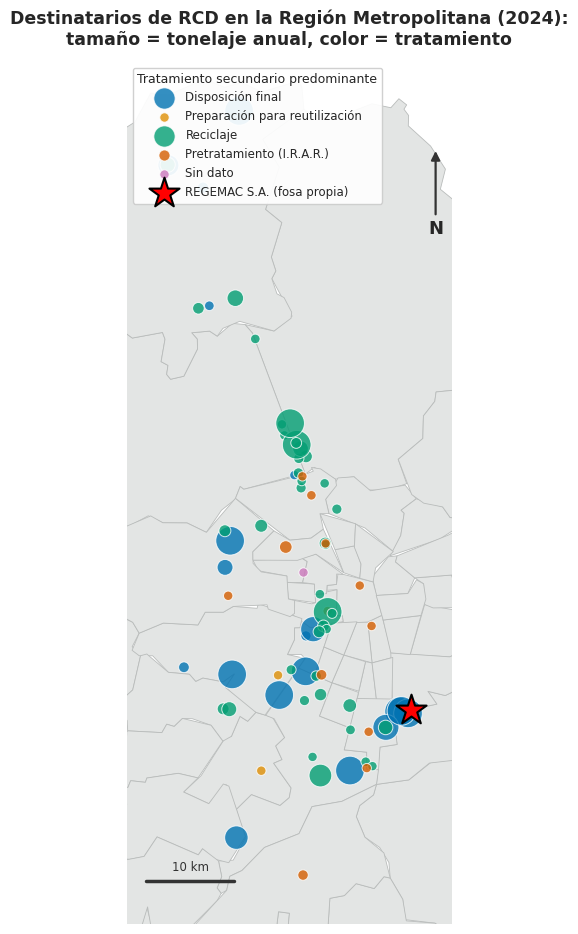

In [ ]:
# Coordenadas de la fosa de Regemac (Troncal San Francisco, Puente Alto)
LAT_REGEMAC, LON_REGEMAC = -33.567, -70.589

margen = 0.05
lon_min_plot = min(mapa_df['longitud'].min(), LON_REGEMAC) - margen
lon_max_plot = max(mapa_df['longitud'].max(), LON_REGEMAC) + margen
lat_min_plot = min(mapa_df['latitud'].min(), LAT_REGEMAC) - margen
lat_max_plot = max(mapa_df['latitud'].max(), LAT_REGEMAC) + margen

fig, ax = plt.subplots(figsize=(9.5, 9.5))
sns.set_theme(style="white")

# --- Fondo: silueta de las comunas de la RM, en gris muy claro ---
parches = []
for anillos in COMUNAS_RM_POLIGONOS.values():
    for anillo in anillos:
        parches.append(MplPolygon(anillo, closed=True))
ax.add_collection(PatchCollection(parches, facecolor='#e3e5e4', edgecolor='#b9bcbb', linewidth=0.6, zorder=0))

ax.set_facecolor('white')
ax.set_xlim(lon_min_plot, lon_max_plot)
ax.set_ylim(lat_min_plot, lat_max_plot)
ax.set_aspect(1 / np.cos(np.radians((lat_min_plot + lat_max_plot) / 2)))

categorias = mapa_df['tratamiento'].fillna('Sin dato').unique()
paleta_tratamiento = dict(zip(categorias, sns.color_palette(PALETA, len(categorias))))

for categoria, color in paleta_tratamiento.items():
    sub = mapa_df[mapa_df['tratamiento'].fillna('Sin dato') == categoria]
    ax.scatter(sub['longitud'], sub['latitud'],
               s=(sub['toneladas'].clip(upper=5000)) / 5000 * 380 + 45,
               alpha=0.8, color=color, edgecolor='white', linewidth=0.7, label=categoria, zorder=3)

ax.scatter(LON_REGEMAC, LAT_REGEMAC, color='red', marker='*', s=520, edgecolor='black', linewidth=1.5,
           label='REGEMAC S.A. (fosa propia)', zorder=5)

# Norte (esquina superior derecha, para no chocar con la leyenda)
ax.annotate('N', xy=(0.95, 0.90), xytext=(0.95, 0.80), xycoords='axes fraction',
            fontsize=13, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='-|>', color='#333333', lw=1.6))

# Escala (barra de 10 km, calculada según la latitud del mapa)
km_por_grado_lon = 111.32 * np.cos(np.radians((lat_min_plot + lat_max_plot) / 2))
largo_barra_km = 10
largo_barra_grados = largo_barra_km / km_por_grado_lon
x0 = lon_min_plot + (lon_max_plot - lon_min_plot) * 0.06
y0 = lat_min_plot + (lat_max_plot - lat_min_plot) * 0.05
ax.plot([x0, x0 + largo_barra_grados], [y0, y0], color='#333333', linewidth=2.5, zorder=4)
ax.text(x0 + largo_barra_grados / 2, y0 + (lat_max_plot - lat_min_plot) * 0.012, f"{largo_barra_km} km",
        ha='center', fontsize=8.5, color='#333333')

ax.set_title(wrap_title("Destinatarios de RCD en la Región Metropolitana (2024): tamaño = tonelaje anual, color = tratamiento", 58),
             fontsize=12.5, fontweight='bold', pad=12)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper left', fontsize=8.5, frameon=True, framealpha=0.92,
          title="Tratamiento secundario predominante", title_fontsize=9)
plt.tight_layout()
plt.show()

Con la silueta de las comunas se aprecia mejor lo que el gráfico original solo insinuaba en el título: Regemac (estrella roja, Puente Alto) está notoriamente más cerca del radio urbano —y por tanto de las obras que generan el residuo— que gran parte de los destinatarios grandes de disposición final, que se concentran hacia el poniente/norte (Til Til, Lampa) y suponen viajes más largos en camión desde el centro y oriente de la ciudad.

---
## 11. Reportes internos de Regemac: estimación de volumen recibido en la fosa (2026)

Todo lo anterior es información pública del RETC (destinatarios finales a nivel de mercado). Esta sección incorpora por primera vez **datos internos de Regemac**: 8 reportes mensuales de envío (enero-agosto de 2026), uno por cada retiro/entrega de contenedor en la fosa de Puente Alto. Son ~20.000 movimientos individuales — mucho más granular que cualquier declaración RETC.

**Para qué sirve esto en el Pilar 3:** Regemac cobra a sus clientes como si el contenedor viniera lleno, por lo que asumir que **todo contenedor retirado llega lleno a la fosa** es razonable y consistente con su propio modelo de cobro. Eso permite convertir movimientos de contenedores en un volumen físico (m³) y, aplicando una densidad de conversión, en toneladas — el primer insumo concreto para cuantificar el "costo de oportunidad de la fosa" que plantea la pauta.

**Ojo con el alcance de esta sección:** aquí solo se completan los pasos 1 y 2 de la cadena de cálculo (movimientos → volumen → tonelaje estimada). **No** se calcula todavía el valor monetario del espacio de fosa: para eso todavía falta que Rodrigo entregue la capacidad remanente de la fosa, la tasa histórica de llenado y el valor de reposición del terreno/celda — datos que, según lo conversado, aún están pendientes.

In [ ]:
meses_envios = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto']

partes_envios = []
for mes in meses_envios:
    url = f"https://raw.githubusercontent.com/fernando25132/Evalpro/refs/heads/main/Reporte%20env%C3%ADos%20{mes}.csv"
    d = pd.read_csv(url)
    d.columns = [c.strip() for c in d.columns]
    d['mes_nombre'] = mes
    partes_envios.append(d)

df_envios = pd.concat(partes_envios, ignore_index=True)
df_envios.columns = [c.strip() for c in df_envios.columns]

# Tamaño del contenedor en m3, a partir de valores como "10_", "9_", "20_"
df_envios['Tipo contenedor'] = df_envios['Tipo contenedor'].astype(str).str.strip()
df_envios['tamano_m3'] = df_envios['Tipo contenedor'].str.extract(r'(\d+)').astype(float)

# Costo declarado en formato chileno ("113.600,00" -> 113600.00)
df_envios['Costo_num'] = (df_envios['Costo'].astype(str)
                           .str.replace('.', '', regex=False)
                           .str.replace(',', '.', regex=False)
                           .astype(float))

df_envios['Obra'] = df_envios['Obra'].astype(str).str.strip()
df_envios['Tipo de envío'] = df_envios['Tipo de envío'].astype(str).str.strip()

print(f"Movimientos totales cargados (8 meses, 2026): {len(df_envios):,}")
print(f"\nTipos de envío:\n{df_envios['Tipo de envío'].value_counts()}")
df_envios.head()

Movimientos totales cargados (8 meses, 2026): 20,091

Tipos de envío:
Tipo de envío
normal                18813
ne_cliente              548
regreso_contenedor      367
ida_contenedor          360
ne_regemac                3
Name: count, dtype: int64


,Código,Correlativo,Estado,Tipo de envío,Tipo de horario,Fecha día,Fecha fijo,Fecha tarde noche,Fecha confirmación final,Costo,...,Chofer,Patente,Guía despacho No. Folio,Medio cobro,Valor del servicio,Contenedor Retirado de Obra,Contenedor entregado en Obra,mes_nombre,tamano_m3,Costo_num
0,EN25-32993,32993,completado,normal,d_a_completo,02/01/2026,NaN,NaN,NaN,"113.600,00",...,Victor Perez,GZSG16,136282.0,NaN,NaN,120.0,176.0,Enero,10.0,113600.0
1,EN25-32994,32994,completado,normal,d_a_completo,02/01/2026,NaN,NaN,NaN,"113.600,00",...,Victor Perez,GZSG16,136283.0,NaN,NaN,160.0,120.0,Enero,10.0,113600.0
2,EN26-1,1,completado,normal,d_a_completo,05/01/2026,NaN,NaN,NaN,"113.600,00",...,Carlos Diaz,RYLP37,136285.0,NaN,NaN,176.0,156.0,Enero,10.0,113600.0
3,EN26-2,2,completado,normal,d_a_completo,05/01/2026,NaN,NaN,NaN,"113.600,00",...,Carlos Diaz,RYLP37,136299.0,NaN,NaN,120.0,176.0,Enero,10.0,113600.0
4,EN26-3,3,completado,normal,d_a_completo,05/01/2026,NaN,NaN,NaN,"101.120,00",...,Luis Neira,BVZR66,136322.0,NaN,NaN,612.0,706.0,Enero,9.0,101120.0


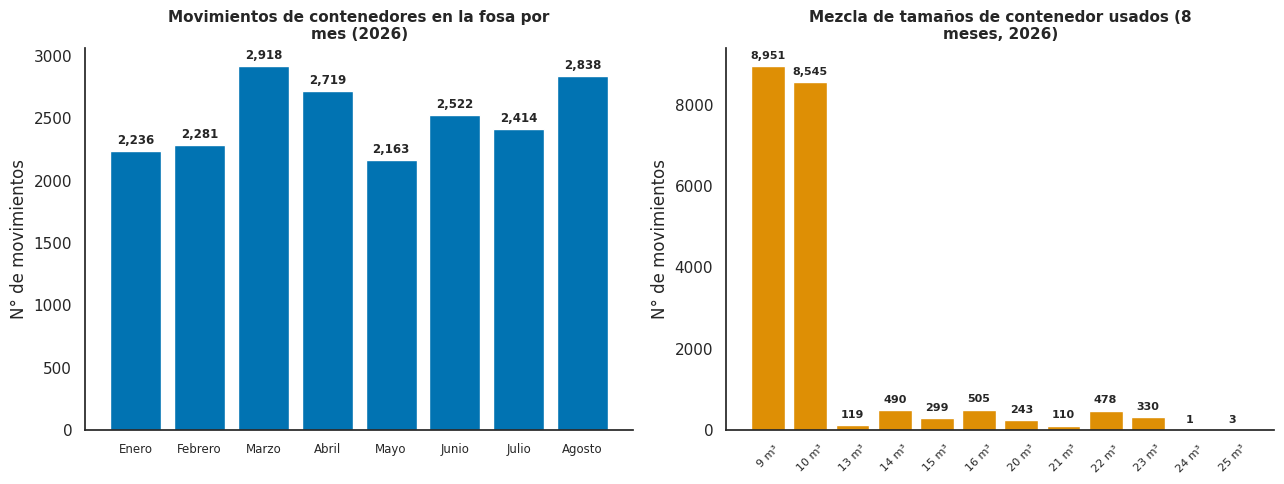

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

movimientos_mes = df_envios.groupby('mes_nombre').size().reindex(meses_envios)
axes[0].bar(meses_envios, movimientos_mes.values, color=sns.color_palette(PALETA)[0])
for x, v in enumerate(movimientos_mes.values):
    axes[0].text(x, v + movimientos_mes.max() * 0.02, f"{v:,}", ha='center', fontsize=8.5, fontweight='bold')
axes[0].set_title(wrap_title("Movimientos de contenedores en la fosa por mes (2026)", 42), fontsize=11, fontweight='bold')
axes[0].set_ylabel("N° de movimientos")
axes[0].tick_params(axis='x', labelsize=8.5)

mezcla_tamanos = df_envios['tamano_m3'].value_counts().sort_index()
axes[1].bar([f"{int(t)} m³" for t in mezcla_tamanos.index], mezcla_tamanos.values, color=sns.color_palette(PALETA)[1])
for x, v in enumerate(mezcla_tamanos.values):
    axes[1].text(x, v + mezcla_tamanos.max() * 0.02, f"{v:,}", ha='center', fontsize=8, fontweight='bold', rotation=0)
axes[1].set_title(wrap_title("Mezcla de tamaños de contenedor usados (8 meses, 2026)", 42), fontsize=11, fontweight='bold')
axes[1].set_ylabel("N° de movimientos")
axes[1].tick_params(axis='x', labelsize=8, rotation=45)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Los movimientos se concentran fuertemente en contenedores de **9 y 10 m³** (~87% del total): son los tamaños "estándar" para escombros y tierra de obra menor. El resto (13 a 25 m³) corresponde a contenedores grandes, probablemente de obras industriales o de mayor escala (como "Planta Romeral", que aparece entre las obras con más movimientos).

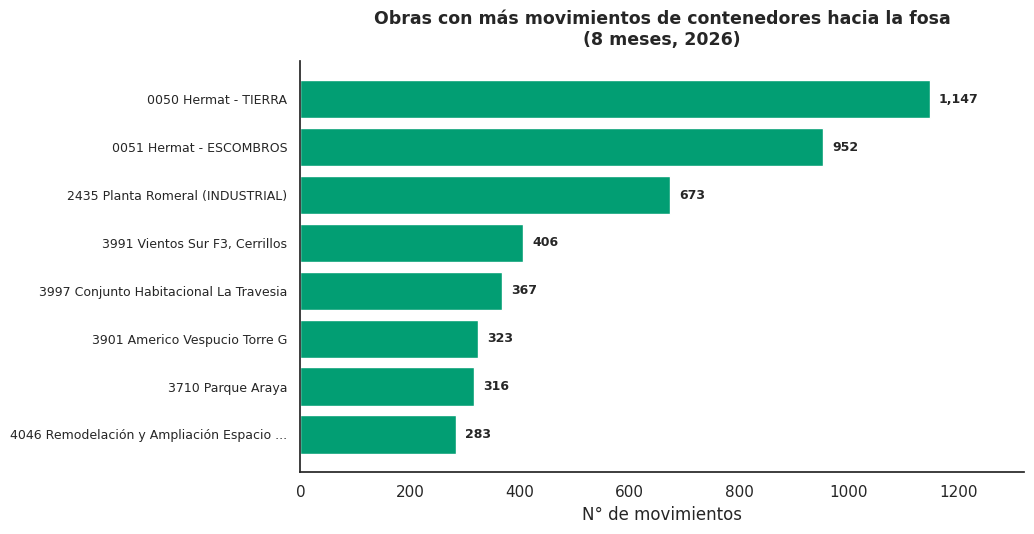

In [ ]:
top_obras = df_envios['Obra'].value_counts().head(8)
labels_obras = [o if len(o) <= 42 else o[:39] + "..." for o in top_obras.index]

fig, ax = plt.subplots(figsize=(10.5, 5.5))
bars = ax.barh(labels_obras[::-1], top_obras.values[::-1], color=sns.color_palette(PALETA)[2])
for b, v in zip(bars, top_obras.values[::-1]):
    ax.text(v + top_obras.max() * 0.015, b.get_y() + b.get_height() / 2, f"{v:,}", va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, top_obras.max() * 1.15)
ax.set_title(wrap_title("Obras con más movimientos de contenedores hacia la fosa (8 meses, 2026)", 55),
             fontsize=12.5, fontweight='bold', pad=12)
ax.set_xlabel("N° de movimientos")
ax.tick_params(axis='y', labelsize=9)
sns.despine()
plt.tight_layout()
plt.show()

Dos obras del mismo cliente ("Hermat", separadas en tierra y escombros) concentran por sí solas más de 2.000 movimientos en 8 meses — más del 10% del total. Vale la pena preguntarle a Rodrigo si estas son obras recurrentes/contratos marco que conviene modelar por separado al proyectar demanda futura de la planta.

In [ ]:
DENSIDAD_BAJA = 320    # kg/m3 - Tabla D.3 NCh3562:2019, "Escombros mixtos" (suelto, sin compactar)
DENSIDAD_ALTA = 1240   # kg/m3 - Tabla D.3 NCh3562:2019, "Inerte (concreto, ladrillos, baldosas)"

# Se usan solo movimientos "normal" (retiro de contenedor lleno desde obra hacia la fosa).
# "ne_cliente" y "ne_regemac" no están claramente definidos en la documentación disponible
# y se excluyen de la estimación de volumen por precaución (quedan como pregunta para Rodrigo).
envios_normales = df_envios[df_envios['Tipo de envío'] == 'normal'].copy()
print(f"Movimientos 'normal' usados para la estimación: {len(envios_normales):,} de {len(df_envios):,} "
      f"({len(envios_normales) / len(df_envios) * 100:.1f}%)")

volumen_mensual_m3 = envios_normales.groupby('mes_nombre')['tamano_m3'].sum().reindex(meses_envios)
volumen_anualizado_m3 = volumen_mensual_m3.mean() * 12

print(f"\nVolumen promedio mensual: {volumen_mensual_m3.mean():,.0f} m³")
print(f"Volumen anualizado (8 meses x 12/8, asumiendo estacionalidad plana): {volumen_anualizado_m3:,.0f} m³/año")

ton_baja = volumen_anualizado_m3 * DENSIDAD_BAJA / 1000
ton_alta = volumen_anualizado_m3 * DENSIDAD_ALTA / 1000
print(f"\nTonelaje anualizado estimado (según densidad de conversión NCh3562):")
print(f"  Escenario bajo (escombro suelto, {DENSIDAD_BAJA} kg/m³):  {ton_baja:,.0f} t/año")
print(f"  Escenario alto (inerte compacto, {DENSIDAD_ALTA} kg/m³):  {ton_alta:,.0f} t/año")

ton_regemac_retc_2024 = 118_457  # de la sección 8.1, tonelaje declarado por Regemac al RETC en 2024
print(f"\nReferencia cruzada — tonelaje que Regemac declaró al RETC como destinatario final en 2024: {ton_regemac_retc_2024:,.0f} t")
print(f"  El escenario bajo ({ton_baja:,.0f} t) equivale a {ton_baja / ton_regemac_retc_2024 * 100:.0f}% de esa cifra.")

Movimientos 'normal' usados para la estimación: 18,813 de 20,091 (93.6%)

Volumen promedio mensual: 25,041 m³
Volumen anualizado (8 meses x 12/8, asumiendo estacionalidad plana): 300,490 m³/año

Tonelaje anualizado estimado (según densidad de conversión NCh3562):
  Escenario bajo (escombro suelto, 320 kg/m³):  96,157 t/año
  Escenario alto (inerte compacto, 1240 kg/m³):  372,608 t/año

Referencia cruzada — tonelaje que Regemac declaró al RETC como destinatario final en 2024: 118,457 t
  El escenario bajo (96,157 t) equivale a 81% de esa cifra.


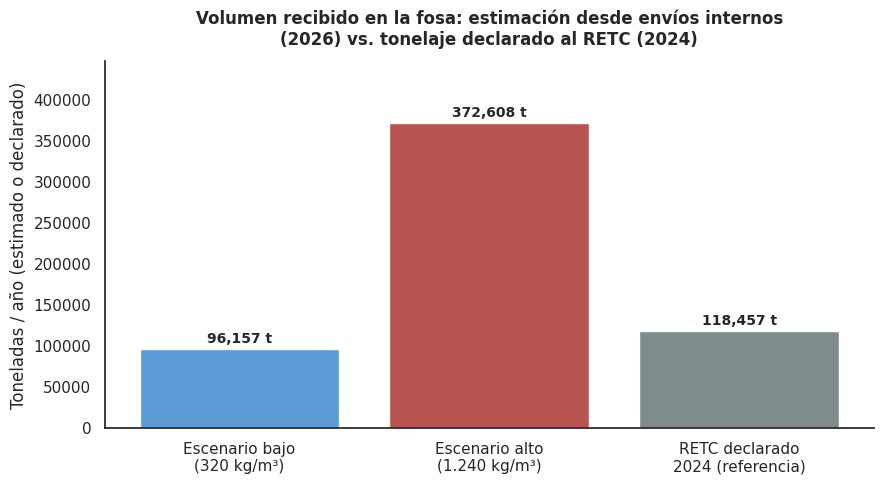

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
escenarios = ['Escenario bajo\n(320 kg/m³)', 'Escenario alto\n(1.240 kg/m³)', 'RETC declarado\n2024 (referencia)']
valores = [ton_baja, ton_alta, ton_regemac_retc_2024]
colores_esc = ['#5B9BD5', '#B85450', '#7f8c8d']
bars = ax.bar(escenarios, valores, color=colores_esc)
for b, v in zip(bars, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + max(valores) * 0.02, f"{v:,.0f} t", ha='center', fontweight='bold', fontsize=10)
ax.set_ylim(0, max(valores) * 1.2)
ax.set_ylabel("Toneladas / año (estimado o declarado)")
ax.set_title(wrap_title("Volumen recibido en la fosa: estimación desde envíos internos (2026) vs. tonelaje declarado al RETC (2024)", 62),
             fontsize=12, fontweight='bold', pad=12)
sns.despine()
plt.tight_layout()
plt.show()

**Lectura y limitaciones, para ser explícito con lo que este cruce sí y no puede afirmar:**

- El escenario bajo de densidad (320 kg/m³, "escombro mixto suelto" según NCh3562) da un resultado del mismo orden de magnitud que el tonelaje que Regemac efectivamente declaró al RETC en 2024 (~81% de esa cifra), lo que es una señal razonable de que la densidad "suelta" es más representativa que la densidad "compactada" para este cálculo — tiene sentido, porque el contenedor se registra en el momento del retiro en obra, **antes** de cualquier compactación con bulldozer en la fosa.
- La comparación cruza dos años distintos (envíos 2026 vs. RETC declarado 2024) y dos fuentes distintas (reporte operativo interno vs. declaración regulatoria), así que el objetivo es **validar el orden de magnitud**, no reconciliar cifras exactas. Parte de la diferencia puede explicarse por crecimiento real del negocio entre 2024 y 2026, por los movimientos excluidos (`ne_cliente`, `ne_regemac`), o por contenedores que no llegan completamente llenos pese al supuesto de cobro.
- Este cálculo entrega **volumen y tonelaje que ingresa a la fosa**, que es distinto del volumen que **ocupa** la fosa una vez compactado — ese paso (factor de compactación con bulldozer, capacidad remanente, vida útil) es exactamente lo que falta para llegar al valor monetario del espacio, y depende de datos operativos de Regemac que Rodrigo todavía no ha entregado.

---
## 12. ¿Quién compra hoy el material segregado? (mercado de venta de segregados)

Análisis nuevo, pensado directamente para el Pilar 1 (mercado de venta de segregados) y para la pregunta del mandante sobre **priorización de materiales**: la base RETC incluye el rubro económico (`rubro`) del establecimiento que recibe cada residuo valorizado. Cruzando eso con el tipo de material, se puede ver qué tan desarrollado está el mercado comprador de cada fracción en la RM.

Se comparan los dos candidatos más obvios a segregar además del fierro: **metales** (subcapítulo LER 04) y el grupo **madera/vidrio/plástico** (subcapítulo LER 02).

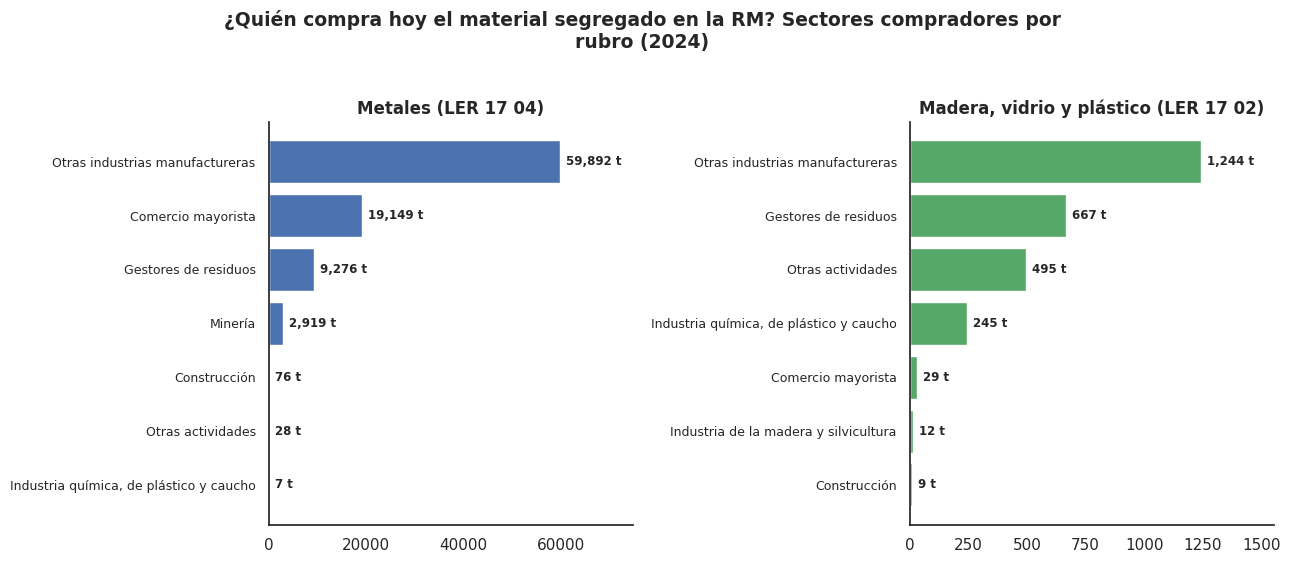

In [ ]:
valorizado_rm = df_rcd_rm[df_rcd_rm['tratamiento_n1_name'] == 'Valorización'].copy()

metales_por_rubro = valorizado_rm[valorizado_rm['LER_numero_subcapitulo'] == 4] \
    .groupby('rubro')['cantidad_toneladas'].sum().sort_values(ascending=True)
plasticos_por_rubro = valorizado_rm[valorizado_rm['LER_numero_subcapitulo'] == 2] \
    .groupby('rubro')['cantidad_toneladas'].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, data, titulo, color in zip(
        axes, [metales_por_rubro, plasticos_por_rubro],
        ["Metales (LER 17 04)", "Madera, vidrio y plástico (LER 17 02)"], ['#4C72B0', '#55A868']):
    bars = ax.barh(data.index, data.values, color=color)
    for b, v in zip(bars, data.values):
        ax.text(v + data.values.max() * 0.02, b.get_y() + b.get_height() / 2, f"{v:,.0f} t",
                va='center', fontsize=8.5, fontweight='bold')
    ax.set_xlim(0, data.values.max() * 1.25)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax)

fig.suptitle(wrap_title("¿Quién compra hoy el material segregado en la RM? Sectores compradores por rubro (2024)", 75),
             fontsize=13.5, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nótese la diferencia de escala en el eje X**: el mercado comprador de metales mueve ~92 mil toneladas/año en la RM (liderado por otras industrias manufactureras — fundiciones y afines — y comercio mayorista de chatarra), mientras que el de madera/vidrio/plástico apenas alcanza ~2,7 mil toneladas/año. Esto es evidencia concreta a favor de lo que el mandante ya intuye con su práctica actual (solo valorizar fierro): el mercado de compradores de plástico segregado en la RM está mucho menos desarrollado, lo que implica mayor riesgo comercial y probablemente menores precios de venta para esa fracción, al menos con la cartera de compradores que hoy declara al RETC. No descarta que existan compradores informales o fuera de este registro, pero sí acota la expectativa.

---
## 13. Síntesis de hallazgos para Regemac

Un resumen de los números que este cuaderno deja disponibles para conectar con las cinco preguntas críticas del mandante y con los pilares P1–P3:

1. **Escala inicial (mandante, pregunta 1):** en la RM se declararon ~2.345 movimientos de RCD en 2024, con Regemac ya presente como destinatario final (~12,4% de participación por tonelaje, ranking #4 de 88 actores). El volumen total valorizado en la RM hoy es bajo (~10% del tonelaje), lo que sugiere espacio de crecimiento importante sin necesariamente desplazar competidores, sino capturando material que hoy va a eliminación. La serie 2021-2024 (sección 5) muestra que Regemac ya aparecía en el RETC en años anteriores (con muestras chicas: 8-22 declaraciones), con una participación entre 12% y 27% — el 12,4% de 2024 es la cifra más confiable por estar construida sobre una muestra mucho mayor.
2. **Priorización de materiales (pregunta 2):** por tonelaje, hormigón/tierra/mezclas inertes y metales dominan el volumen; el mercado comprador de metales está consolidado (~92 kt/año en la RM) mientras que el de plástico segregado es marginal (~2,7 kt/año) — esto debiera ponderar la secuencia de materiales a incorporar en la primera etapa.
3. **Conveniencia económica (pregunta 3):** la brecha entre el 52% (declaraciones) y el 89% (tonelaje) de material que hoy va a eliminación es, en la práctica, el tamaño de la oportunidad que la planta busca capturar — insumo directo para el modelo de ingresos por valorización del Pilar 3. Los reportes internos de envíos (sección 11) permiten además una primera estimación de volumen físico que llega a la fosa hoy (~96 mil t/año en el escenario de densidad más plausible, del mismo orden que el tonelaje declarado por Regemac al RETC), que es el punto de partida para cuantificar el costo de oportunidad de ese espacio — aunque el cálculo del valor monetario en sí todavía requiere datos operativos de la fosa (capacidad remanente, tasa de llenado, compactación) que están pendientes de parte de Rodrigo.
4. **Riesgos (pregunta 4):** la concentración de mercado es moderada por tonelaje (IHH ≈ 1.458) pero baja por conteo de declaraciones (IHH ≈ 510) — hay varios actores medianos, no un monopolio, lo que reduce el riesgo de dependencia de un solo comprador pero también indica que ganar participación requiere competir en precio/servicio. La serie multi-año (sección 5) es un recordatorio de que las cifras de participación de mercado de años con pocas declaraciones (2021-2023) son poco confiables y no deben usarse solas para proyectar tendencia.
5. **Escalamiento (pregunta 5):** este cuaderno se concentra en la RM (Caso Base y CBO); el mapa y las cifras de mercado quedan estructurados para poder replicarse en otras regiones cuando corresponda abrir el Pilar 4.

### Limitaciones a documentar (Anexo 2)
- Un año único de datos con detalle mensual (2024): no permite distinguir estacionalidad real de ruido de reporte, y ningún año anterior (2021-2023) trae fecha o mes, por lo que la estacionalidad no se puede validar contra series históricas.
- El salto de ~46-271 declaraciones anuales (2021-2023) a ~2.345 declaraciones granulares (2024) refleja, con alta probabilidad, un cambio en la forma de reportar al RETC y no un crecimiento real del mercado — las comparaciones entre años se hacen por tonelaje, no por conteo.
- ~164 declaraciones marcadas como región RM con coordenadas fuera de la RM (error de estandarización RETC) — excluidas del mapa, mantenidas en los conteos agregados.
- El campo `rubro` clasifica al establecimiento receptor, no necesariamente su uso final del material — es una aproximación al comprador, no una confirmación de venta.
- La estimación de volumen a partir de los envíos internos de Regemac (sección 11) asume contenedores siempre llenos (consistente con el modelo de cobro) y excluye movimientos `ne_cliente`/`ne_regemac` por no tener su definición exacta — ambos supuestos deberían validarse directamente con Rodrigo.
- El mapa geográfico usa un fondo de siluetas de comunas embebido en el propio cuaderno (no depende de servicios externos de mapas), por lo que su apariencia es siempre la misma sin importar la conectividad al ejecutar la celda.